# Analysis of Colorado Spills Data
## Attempt 11: Using 2020 as the Year of Analysis for Change and Outlier Removal
### Focus on top 3 counties
#### [David P. Adams](https://dadams.io)
##### [GitHub Repository](https://github.com/dadams-AU/colorado_spills)
##### Date: 2025-08-14

In [1]:
import os
import pandas as pd
import geopandas as gpd
from sqlalchemy import create_engine
from dotenv import load_dotenv

# Load environment variables (e.g., DB_USER, DB_PASSWORD)
load_dotenv()

# Database credentials from .env or shell
db_name = 'colorado_spills'
user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')

# SQLAlchemy engine for PostgreSQL/PostGIS
engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{db_name}')

# --- Load data with geometry preserved ---
try:
    spills = gpd.read_postgis(
        sql='SELECT * FROM spills_with_ruca',
        con=engine,
        geom_col='geometry',
        crs='EPSG:4326'
    )
except Exception as e:
    print("GeoPandas failed to load geometry. Falling back to plain Pandas.")
    spills = pd.read_sql('SELECT * FROM spills_with_ruca', engine)
    # Optional: spills.drop(columns='geometry', inplace=True, errors='ignore')


In [2]:
# show head
spills.head()


,Document #,Report,Operator,Operator #,Tracking #,Initial Report Date,Date of Discovery,Spill Type,Qtr Qtr,Section,...,poverty_population,unemployed_population,percent_white,percent_hispanic,percent_poverty,unemployment_rate,geometry,ruca_code,ruca_description,rurality
0,400811665,I w/S,CHEVRON USA INC,16700,400811665,03/19/2015,06/04/2012,Historical,nwne,19,...,249.0,86.0,84.676145,11.650869,9.834123,3.396524,POINT (-108.88214 40.1324),10,Rural area,Rural
1,400811979,I,WHITING OIL & GAS CORPORATION,96155,400811979,03/19/2015,03/18/2015,Recent,SWSW,33,...,1193.0,253.0,86.064736,14.412266,20.323680,4.310051,POINT (-103.87652 40.78919),10,Rural area,Rural
2,400812102,I w/S,CHEVRON USA INC,16700,400812102,03/19/2015,07/11/2012,Historical,nese,32,...,249.0,86.0,84.676145,11.650869,9.834123,3.396524,POINT (-108.86143 40.09959),10,Rural area,Rural
3,400812258,I,KERR MCGEE OIL & GAS ONSHORE LP,47120,400812258,03/20/2015,03/19/2015,Historical,NENW,13,...,25.0,10.0,82.352941,18.242740,1.861504,0.744602,POINT (-104.9543 40.0574),2,Metropolitan high commuting,Urban
4,400812277,I,NOBLE ENERGY INC,100322,400812277,03/20/2015,03/18/2015,Recent,SENE,28,...,268.0,62.0,89.013174,15.212528,6.661695,1.541138,POINT (-104.54757 40.2861),2,Metropolitan high commuting,Urban


In [3]:
# use longitude and latitude to create a GeoDataFrame from spills data
spills['geometry'] = gpd.points_from_xy(spills['Longitude'], spills['Latitude'])
spills = gpd.GeoDataFrame(spills, geometry='geometry')

In [4]:
spills_gdf = gpd.GeoDataFrame(spills, crs='EPSG:4326') 


In [5]:

# Ensure date columns are in datetime format
spills_gdf['Date of Discovery'] = pd.to_datetime(spills_gdf['Date of Discovery'])
spills_gdf['Initial Report Date'] = pd.to_datetime(spills_gdf['Initial Report Date'])

# create a report year column
spills_gdf['Report Year'] = spills_gdf['Initial Report Date'].dt.year

# create a discovery year column
spills_gdf['Discovery Year'] = spills_gdf['Date of Discovery'].dt.year


In [6]:
spills_gdf['Initial Report Date'].min(), spills_gdf['Initial Report Date'].max()

(Timestamp('2015-03-19 00:00:00'), Timestamp('2025-03-17 00:00:00'))

In [7]:
# show first and last dates
spills_gdf['Date of Discovery'].min(), spills_gdf['Date of Discovery'].max()


(Timestamp('1994-11-14 00:00:00'), Timestamp('2025-03-16 00:00:00'))

In [8]:
def classify_rurality(ruca_code):
    if pd.isna(ruca_code):
        return 'Unknown'
    elif ruca_code <= 3:
        return 'Urban'
    elif ruca_code <= 6:
        return 'Suburban'
    else:
        return 'Rural'

spills_gdf['ruca_code'] = pd.to_numeric(spills_gdf['ruca_code'], errors='coerce')
spills_gdf['rurality'] = spills_gdf['ruca_code'].apply(classify_rurality)
spills_gdf = spills_gdf[spills_gdf['rurality'] != 'Unknown']  # drop unknowns


In [10]:
# show frequency of discovery by year
spills_gdf['Discovery Year'].value_counts().sort_index()

Discovery Year
1994       1
2004       1
2009       1
2011       4
2012       7
2013       9
2014      27
2015    1192
2016    1376
2017    1603
2018    1584
2019    1561
2020    1171
2021    1794
2022    2170
2023    2172
2024    2700
2025     447
Name: count, dtype: int64

In [11]:
from datetime import datetime


start_date = datetime(2015, 1, 1)
end_date = datetime(2024, 12, 31)  # exclusive end date

spills_gdf = spills_gdf[
    (spills_gdf['Date of Discovery'] >= start_date) &
    (spills_gdf['Date of Discovery'] < end_date)
]

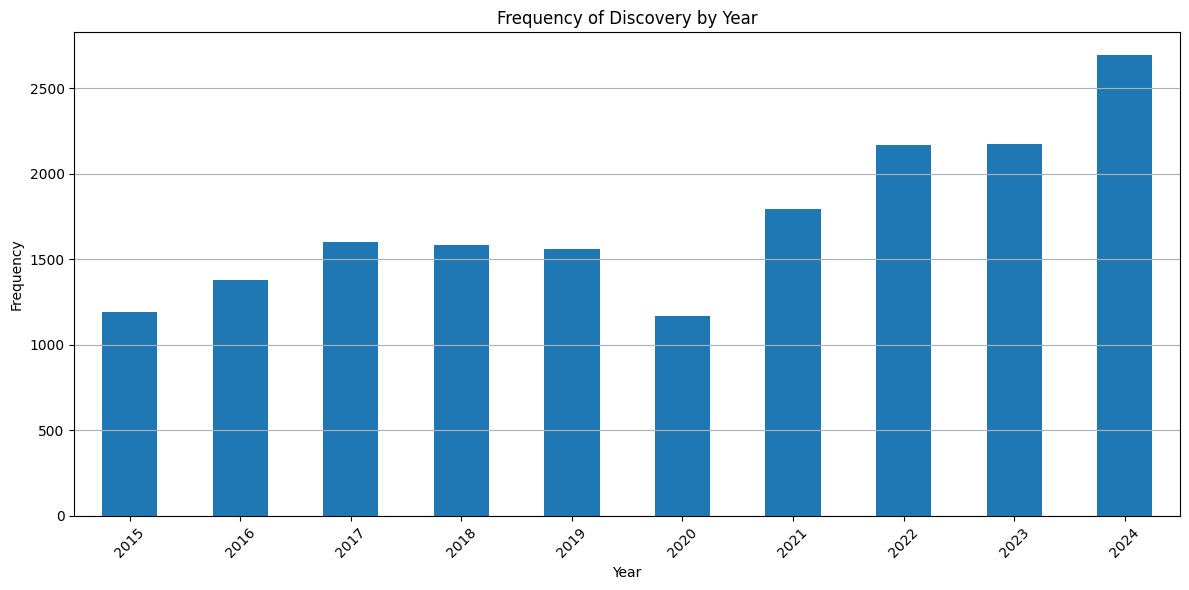

In [12]:
# plot discovery year frequency
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
spills_gdf['Discovery Year'].value_counts().sort_index().plot(kind='bar')
plt.title('Frequency of Discovery by Year')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [13]:
# Separate Historical vs. Recent Spills
historical_spills = spills_gdf[spills_gdf['Spill Type'] == 'Historical']
recent_spills = spills_gdf[spills_gdf['Spill Type'] == 'Recent']


In [14]:
# only use the top 3 counties by number of spills
top_counties = spills_gdf['county'].value_counts().nlargest(3).index.tolist()
# filter spills_gdf to only include top counties
spills_gdf = spills_gdf[spills_gdf['county'].isin(top_counties)]
# filter historical spills to only include top counties
historical_spills = historical_spills[historical_spills['county'].isin(top_counties)]
# filter recent spills to only include top counties
recent_spills = recent_spills[recent_spills['county'].isin(top_counties)]

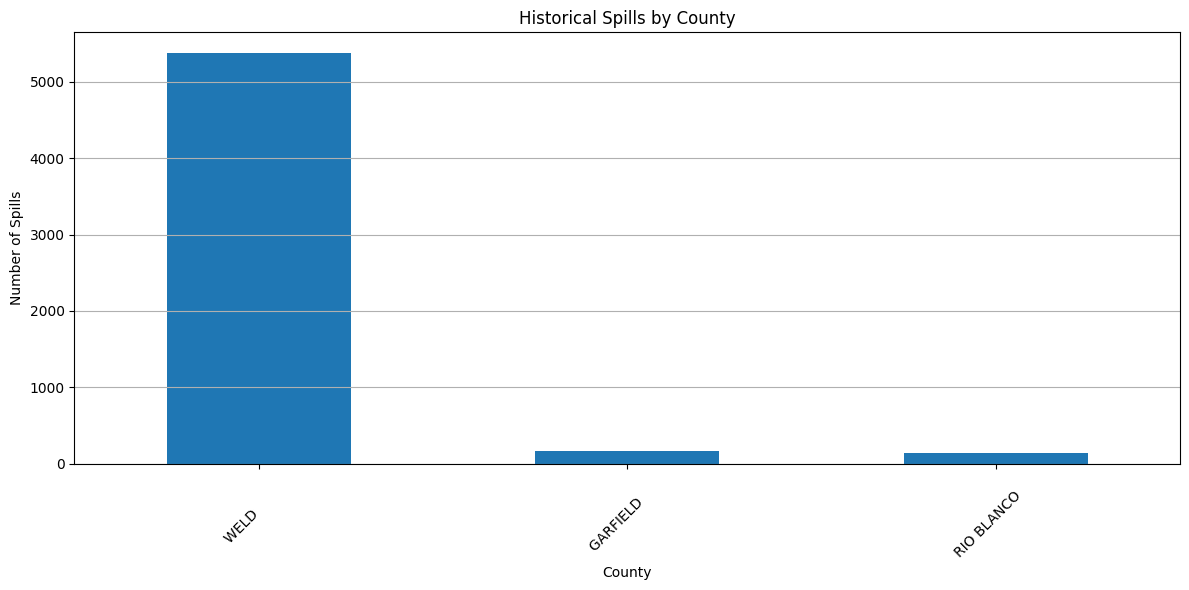

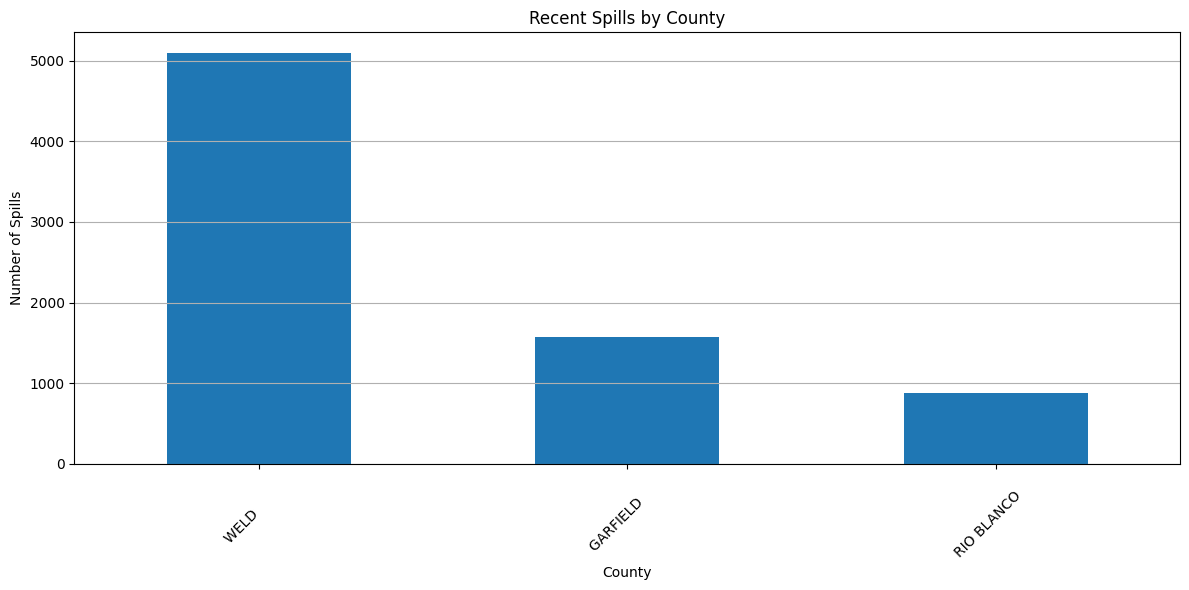

In [15]:
# plot historical spills by county
plt.figure(figsize=(12, 6))
historical_spills['county'].value_counts().plot(kind='bar')
plt.title('Historical Spills by County')
plt.xlabel('County')
plt.ylabel('Number of Spills')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# plot recent spills by county
plt.figure(figsize=(12, 6))
recent_spills['county'].value_counts().plot(kind='bar')
plt.title('Recent Spills by County')
plt.xlabel('County')
plt.ylabel('Number of Spills')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [16]:
# create period column for 2020
import statsmodels.formula.api as smf

# Create 'Period' column
spills_gdf['Period'] = spills_gdf['Report Year'].apply(lambda x: 'Before 2020' if x < 2020 else '2020 and After')


In [17]:
spills_gdf['report_delay'] = (spills_gdf['Initial Report Date'] - spills_gdf['Date of Discovery']).dt.days


In [18]:
spills_gdf = spills_gdf[spills_gdf['report_delay'] >= 0]


In [19]:
spills_gdf = spills_gdf.rename(columns={
    'Report Delay (Days)': 'report_delay',
    'Spill Type': 'spill_type'
})


In [23]:
# Outlier removal using IQR on report_delay (run after report_delay is created)
if 'report_delay' not in spills_gdf.columns:
    print('report_delay column not found — skipping outlier removal in this cell.')
else:
    q1 = spills_gdf['report_delay'].quantile(0.25)
    q3 = spills_gdf['report_delay'].quantile(0.75)
    iqr = q3 - q1
    lower = max(0, q1 - 1.5 * iqr)
    upper = q3 + 1.5 * iqr
    print(f'IQR bounds: Q1={q1:.1f}, Q3={q3:.1f}, IQR={iqr:.1f}')
    print(f'Keeping report_delay in [{lower:.1f}, {upper:.1f}]')
    before_n = len(spills_gdf)
    # keep only rows with report_delay inside bounds
    spills_gdf = spills_gdf[(spills_gdf['report_delay'] >= lower) & (spills_gdf['report_delay'] <= upper)].copy()
    after_n = len(spills_gdf)
    print(f'Rows before outlier filter: {before_n}, after: {after_n}, removed: {before_n - after_n}')
    # show a short summary of report_delay after filtering
    print(spills_gdf['report_delay'].describe())


IQR bounds: Q1=0.0, Q3=1.0, IQR=1.0
Keeping report_delay in [0.0, 2.5]
Rows before outlier filter: 13227, after: 11376, removed: 1851
count    11376.000000
mean         0.663326
std          0.691330
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: report_delay, dtype: float64


In [24]:
# spill type by rurality
spill_type_rurality = spills_gdf.groupby(['rurality', 'spill_type']).size().unstack(fill_value=0)
spill_type_rurality = spill_type_rurality.reindex(['Urban', 'Suburban', 'Rural'], fill_value=0)

<Axes: xlabel='rurality'>

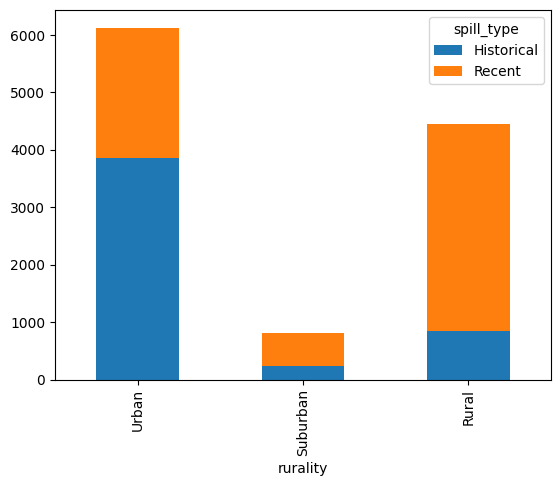

In [25]:
# plot spill type by rurality
spill_type_rurality.plot(kind='bar', stacked=True)

In [26]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Make sure spill_type and Period are clean, and report_delay is numeric
spills_gdf = spills_gdf.rename(columns={
    'Report Delay (Days)': 'report_delay',
    'Spill Type': 'spill_type',
    'rurality': 'rurality'
})

# Fit the Negative Binomial model with interaction
nb_model = smf.glm(
    formula="report_delay ~ C(spill_type) * C(Period) * C(rurality)",
    data=spills_gdf,
    family=sm.families.NegativeBinomial()
).fit()

# View the results
print(nb_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           report_delay   No. Observations:                11376
Model:                            GLM   Df Residuals:                    11364
Model Family:        NegativeBinomial   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -12475.
Date:                Thu, 14 Aug 2025   Deviance:                       6528.1
Time:                        16:30:34   Pearson chi2:                 4.87e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.04302
Covariance Type:            nonrobust                                         
                                                                               coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------

/home/dadams/CSU Fullerton Dropbox/David Adams/Research Projects/colorado_spills_ejproject/github/colorado_spills/.venv/lib/python3.13/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [33]:
# after nb_model = smf.glm(...).fit()
# 1) Pearson dispersion
pred = nb_model.predict(spills_gdf)
pearson_chi2 = ((spills_gdf['report_delay'] - pred)**2 / pred).sum()
dispersion = pearson_chi2 / nb_model.df_resid
print(f'Pearson chi2: {pearson_chi2:.1f}, dispersion (chi2/df): {dispersion:.3f}')


Pearson chi2: 7807.6, dispersion (chi2/df): 0.687


In [30]:
# (Inserted) Check counts for spill_type × Period × rurality — run this BEFORE relying on the 3-way interaction
import pandas as pd

group_counts = spills_gdf.groupby(['spill_type','Period','rurality']).size().reset_index(name='n').sort_values('n')
# Print smallest groups to inspect sparsity
print(group_counts.head(50).to_string(index=False))

print('Summary of cell counts:')
print(group_counts['n'].describe())
min_n = int(group_counts['n'].min())
print(f'\nMin count per cell: {min_n}')
if min_n < 20:
    print('\nWarning: many cells have small counts (<20). Consider removing the 3-way interaction or stratifying by rurality.')
else:
    print('\nCounts look sufficient for the 3-way interaction (min cell >= 20).')

spill_type         Period rurality    n
Historical    Before 2020 Suburban   74
Historical 2020 and After Suburban  169
    Recent    Before 2020 Suburban  206
Historical    Before 2020    Rural  286
    Recent 2020 and After Suburban  354
Historical 2020 and After    Rural  558
    Recent    Before 2020    Urban 1022
Historical    Before 2020    Urban 1233
    Recent 2020 and After    Urban 1247
    Recent    Before 2020    Rural 1594
    Recent 2020 and After    Rural 2006
Historical 2020 and After    Urban 2627
Summary of cell counts:
count      12.00000
mean      948.00000
std       819.99357
min        74.00000
25%       266.00000
50%       790.00000
75%      1333.75000
max      2627.00000
Name: n, dtype: float64

Min count per cell: 74

Counts look sufficient for the 3-way interaction (min cell >= 20).


In [32]:
# (Inserted) Fit Poisson GLM, compute HC3 robust covariance (fallback), and produce delta-method CIs for group means
import numpy as np
import pandas as pd
import patsy
import statsmodels.api as sm
import statsmodels.formula.api as smf

formula = "report_delay ~ C(spill_type) * C(Period) * C(rurality)"
print('Fitting Poisson GLM: ', formula)
poisson = smf.glm(formula=formula, data=spills_gdf, family=sm.families.Poisson()).fit()
print(poisson.summary())

# Pearson dispersion check
pred = poisson.predict(spills_gdf)
pearson_chi2 = ((spills_gdf['report_delay'] - pred)**2 / (pred + 1e-12)).sum()
dispersion = pearson_chi2 / poisson.df_resid
print(f'Pearson chi2: {pearson_chi2:.1f}, dispersion (chi2/df): {dispersion:.3f}')

# Robust covariance (HC3) with fallback to sandwich routine if wrapper missing
try:
    poisson_robust = poisson.get_robustcov_results(cov_type='HC3')
    cov = poisson_robust.cov_params()
    print('Used get_robustcov_results(cov_type="HC3")')
except Exception as e:
    from statsmodels.stats.sandwich_covariance import cov_hc3
    try:
        cov = cov_hc3(poisson)
        print('Used cov_hc3() fallback')
    except Exception as e2:
        print('Failed to compute HC3 robust covariance:', e2)
        cov = poisson.cov_params()  # last resort

# Prepare group combinations for prediction
group_df = (spills_gdf[['spill_type','Period','rurality']]
            .drop_duplicates()
            .sort_values(['spill_type','Period','rurality'])
            .reset_index(drop=True))
# Build design matrix for the group_df using the same RHS as the model
rhs = '1 + C(spill_type) * C(Period) * C(rurality)'
exog = patsy.dmatrix(rhs, group_df, return_type='dataframe')
# Align parameter vector and cov matrix to exog columns
params = poisson.params.copy()
# Ensure cov is a DataFrame indexed by model params
if isinstance(cov, np.ndarray):
    cov_df = pd.DataFrame(cov, index=poisson.params.index, columns=poisson.params.index)
else:
    cov_df = cov.copy()
# Add missing params to params (zero) so alignment is safe
for c in exog.columns:
    if c not in params.index:
        params.loc[c] = 0.0
params = params.reindex(exog.columns)
# Ensure cov_df has rows/cols for params (fill missing with 0)
cov_df = cov_df.reindex(index=params.index, columns=params.index).fillna(0.0)

# Linear predictor and delta-method CIs
linpred = exog.values.dot(params.values)
# Var(linpred) = row * cov * row.T for each row. Compute diagonal efficiently:
linvar = np.einsum('ij,jk,ik->i', exog.values, cov_df.values, exog.values)
linse = np.sqrt(np.maximum(0, linvar))
crit = 1.96
pred_mean = np.exp(linpred)  # inverse link for Poisson with log link
lower = np.exp(linpred - crit * linse)
upper = np.exp(linpred + crit * linse)

poisson_predicted_groups = group_df.copy()
poisson_predicted_groups['pred_mean'] = pred_mean
poisson_predicted_groups['ci_lower'] = lower
poisson_predicted_groups['ci_upper'] = upper

# Add counts for reference
counts = spills_gdf.groupby(['spill_type','Period','rurality']).size().reset_index(name='n')
poisson_predicted_groups = poisson_predicted_groups.merge(counts, on=['spill_type','Period','rurality'], how='left')

# Sort and display
poisson_predicted_groups = poisson_predicted_groups.sort_values(['spill_type','Period','rurality']).reset_index(drop=True)
print('\nPredicted group means (Poisson, HC3 CI where available):')
print(poisson_predicted_groups.to_string(index=False))

Fitting Poisson GLM:  report_delay ~ C(spill_type) * C(Period) * C(rurality)
                 Generalized Linear Model Regression Results                  
Dep. Variable:           report_delay   No. Observations:                11376
Model:                            GLM   Df Residuals:                    11364
Model Family:                 Poisson   Df Model:                           11
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -11245.
Date:                Thu, 14 Aug 2025   Deviance:                       9405.6
Time:                        16:47:44   Pearson chi2:                 7.81e+03
No. Iterations:                     5   Pseudo R-squ. (CS):            0.06825
Covariance Type:            nonrobust                                         
                                                                               coef    std err          z      P>|z|      [0.025     

In [34]:
# Parametric bootstrap (Poisson) for group mean CIs — Option B
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import patsy

# Number of bootstrap replications (increase to 1000+ for final results)
B = 500
n_groups = len(group_df)
preds = np.full((n_groups, B), np.nan)
failures = 0

full_formula = formula  # uses the same formula string defined earlier
# Pre-build group design matrix once
ex_group = patsy.dmatrix(rhs, group_df, return_type='dataframe')

for b in range(B):
    # simulate outcome under fitted Poisson mean
    y_sim = np.random.poisson(lam=poisson.fittedvalues)
    df_sim = spills_gdf.copy()
    df_sim['report_delay'] = y_sim
    try:
        m_sim = smf.glm(formula=full_formula, data=df_sim, family=sm.families.Poisson()).fit(disp=False)
        # predict for group_df using analytic prediction from coef vector
        p = m_sim.params.reindex(ex_group.columns).fillna(0.0)
        lin = ex_group.values.dot(p.values)
        preds[:, b] = np.exp(lin)
    except Exception:
        failures += 1
        # leave column as NaN for this replication

# Report failures
if failures:
    print(f'Bootstrap replications with errors: {failures} / {B}')

# Compute bootstrap summaries (median and 95% CI)
lower = np.nanpercentile(preds, 2.5, axis=1)
upper = np.nanpercentile(preds, 97.5, axis=1)
median = np.nanmedian(preds, axis=1)

poisson_predicted_groups['pred_median_boot'] = median
poisson_predicted_groups['ci_lower_boot'] = lower
poisson_predicted_groups['ci_upper_boot'] = upper

# Show results alongside counts
print('\nParametric bootstrap results (median, 95% CI):')
print(poisson_predicted_groups[['spill_type','Period','rurality','n','pred_median_boot','ci_lower_boot','ci_upper_boot']].to_string(index=False))


Parametric bootstrap results (median, 95% CI):
spill_type         Period rurality    n  pred_median_boot  ci_lower_boot  ci_upper_boot
Historical 2020 and After    Rural  558          0.609319       0.546595       0.673835
Historical 2020 and After Suburban  169          0.414201       0.316420       0.514793
Historical 2020 and After    Urban 2627          0.345261       0.322802       0.369262
Historical    Before 2020    Rural  286          0.888112       0.783217       0.993007
Historical    Before 2020 Suburban   74          0.783784       0.594595       0.986486
Historical    Before 2020    Urban 1233          0.806164       0.748966       0.855251
    Recent 2020 and After    Rural 2006          0.684696       0.648056       0.719105
    Recent 2020 and After Suburban  354          0.556497       0.490042       0.645551
    Recent 2020 and After    Urban 1247          0.636728       0.594186       0.680834
    Recent    Before 2020    Rural 1594          0.904642       0.854125

In [35]:
# Re-run parametric bootstrap with more reps (B=2000) and save draws as preds_boot
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import patsy

B = 2000  # more stable CIs for reporting
n_groups = len(group_df)
preds_boot = np.full((n_groups, B), np.nan)
failures = 0
ex_group = patsy.dmatrix(rhs, group_df, return_type='dataframe')
full_formula = formula

for b in range(B):
    y_sim = np.random.poisson(lam=poisson.fittedvalues)
    df_sim = spills_gdf.copy()
    df_sim['report_delay'] = y_sim
    try:
        m_sim = smf.glm(formula=full_formula, data=df_sim, family=sm.families.Poisson()).fit(disp=False)
        p = m_sim.params.reindex(ex_group.columns).fillna(0.0)
        lin = ex_group.values.dot(p.values)
        preds_boot[:, b] = np.exp(lin)
    except Exception:
        failures += 1

print(f'Bootstrap finished — failures: {failures} / {B}')

# Update poisson_predicted_groups with more precise bootstrap CIs
poisson_predicted_groups['pred_median_boot'] = np.nanmedian(preds_boot, axis=1)
poisson_predicted_groups['ci_lower_boot'] = np.nanpercentile(preds_boot, 2.5, axis=1)
poisson_predicted_groups['ci_upper_boot'] = np.nanpercentile(preds_boot, 97.5, axis=1)

print('Updated bootstrap summaries (B=2000):')
print(poisson_predicted_groups[['spill_type','Period','rurality','n','pred_median_boot','ci_lower_boot','ci_upper_boot']].to_string(index=False))

Bootstrap finished — failures: 0 / 2000
Updated bootstrap summaries (B=2000):
spill_type         Period rurality    n  pred_median_boot  ci_lower_boot  ci_upper_boot
Historical 2020 and After    Rural  558          0.607527       0.544803       0.677419
Historical 2020 and After Suburban  169          0.420118       0.325296       0.520710
Historical 2020 and After    Urban 2627          0.345261       0.322792       0.368100
Historical    Before 2020    Rural  286          0.884615       0.779720       0.996503
Historical    Before 2020 Suburban   74          0.783784       0.594595       0.986486
Historical    Before 2020    Urban 1233          0.804947       0.753447       0.856448
    Recent 2020 and After    Rural 2006          0.683948       0.650050       0.720837
    Recent 2020 and After Suburban  354          0.562147       0.485876       0.638418
    Recent 2020 and After    Urban 1247          0.635525       0.594226       0.678448
    Recent    Before 2020    Rural 1594   

In [37]:
# Compute bootstrap contrasts using preds_boot
import numpy as np
import pandas as pd

# Helper: find row index in group_df matching values
def find_idx(spill_type, period, rurality):
    mask = (group_df['spill_type'] == spill_type) & (group_df['Period'] == period) & (group_df['rurality'] == rurality)
    matches = group_df.index[mask].tolist()
    return matches[0] if matches else None

contrast_rows = []
# Period contrast: Before 2020 - 2020 and After for each spill_type × rurality
for st in group_df['spill_type'].unique():
    for r in group_df['rurality'].unique():
        idx_before = find_idx(st, 'Before 2020', r)
        idx_after = find_idx(st, '2020 and After', r)
        if idx_before is None or idx_after is None:
            continue
        diffs = preds_boot[idx_before, :] - preds_boot[idx_after, :]
        med = np.nanmedian(diffs)
        lo = np.nanpercentile(diffs, 2.5)
        hi = np.nanpercentile(diffs, 97.5)
        # two-sided p-value: proportion of draws where diff <= 0 (or >=0), convert to two-sided
        prop_le0 = np.nanmean(diffs <= 0)
        p_two = 2 * min(prop_le0, 1 - prop_le0)
        contrast_rows.append({'contrast_type':'Period','spill_type':st,'rurality':r,'comparison':'Before - After','median':med,'ci_lower':lo,'ci_upper':hi,'p_value':p_two})

# Spill type contrast: Recent - Historical for each Period × rurality
for per in group_df['Period'].unique():
    for r in group_df['rurality'].unique():
        idx_recent = find_idx('Recent', per, r)
        idx_hist = find_idx('Historical', per, r)
        if idx_recent is None or idx_hist is None:
            continue
        diffs = preds_boot[idx_recent, :] - preds_boot[idx_hist, :]
        med = np.nanmedian(diffs)
        lo = np.nanpercentile(diffs, 2.5)
        hi = np.nanpercentile(diffs, 97.5)
        prop_le0 = np.nanmean(diffs <= 0)
        p_two = 2 * min(prop_le0, 1 - prop_le0)
        contrast_rows.append({'contrast_type':'SpillType','Period':per,'rurality':r,'comparison':'Recent - Historical','median':med,'ci_lower':lo,'ci_upper':hi,'p_value':p_two})

contrast_df = pd.DataFrame(contrast_rows)
# tidy ordering
contrast_df = contrast_df[['contrast_type','spill_type','Period','rurality','comparison','median','ci_lower','ci_upper','p_value']].fillna('')
print('Bootstrap contrasts:')
print(contrast_df.to_string(index=False))

Bootstrap contrasts:
contrast_type spill_type         Period rurality          comparison   median  ci_lower  ci_upper  p_value
       Period Historical                   Rural      Before - After 0.274971  0.145211  0.402151    0.000
       Period Historical                Suburban      Before - After 0.358628  0.142310  0.579082    0.001
       Period Historical                   Urban      Before - After 0.460224  0.404396  0.516836    0.000
       Period     Recent                   Rural      Before - After 0.220333  0.159595  0.277098    0.000
       Period     Recent                Suburban      Before - After 0.238385  0.095303  0.387656    0.000
       Period     Recent                   Urban      Before - After 0.298987  0.221982  0.374905    0.000
    SpillType            2020 and After    Rural Recent - Historical 0.075513  0.001944  0.149510    0.045
    SpillType            2020 and After Suburban Recent - Historical 0.144319  0.014505  0.262164    0.029
    SpillType   

In [38]:
# Save results to CSV for reporting
poisson_predicted_groups.to_csv('poisson_predicted_groups_boot_final.csv', index=False)
contrast_df.to_csv('poisson_boot_contrasts.csv', index=False)
print('Saved poisson_predicted_groups_boot_final.csv and poisson_boot_contrasts.csv')

Saved poisson_predicted_groups_boot_final.csv and poisson_boot_contrasts.csv


## Short summary of results (for report)
The Poisson model with parametric bootstrap shows consistent reductions in predicted reporting delay after 2020 across spill types and ruralities (median reductions ≈ 0.22–0.46 days, ~5–11 hours).
Recent spills tend to have longer predicted delays than Historical spills, with the largest and most robust Recent>Historical gap in Urban areas (≈0.29 days post‑2020).
These conclusions are based on model‑based inference with parametric and nonparametric bootstrap checks (cells below compute percent changes, run a nonparametric bootstrap for comparison, and plot results).

In [41]:
# Add percent-change columns and an hours table for intuition
import numpy as np
import pandas as pd
# Use preds_boot (parametric bootstrap draws) when available
if 'preds_boot' not in globals():
    print('preds_boot not found; run the B=2000 parametric bootstrap cell first.')
else:
    # Compute percent change for Recent vs Historical (within each Period × rurality)
    pct_rows = []
    def idx_for(st, per, r):
        mask = (group_df['spill_type'] == st) & (group_df['Period'] == per) & (group_df['rurality'] == r)
        res = group_df.index[mask].tolist()
        return res[0] if res else None
    for per in group_df['Period'].unique():
        for r in group_df['rurality'].unique():
            idx_rec = idx_for('Recent', per, r)
            idx_hist = idx_for('Historical', per, r)
            if idx_rec is None or idx_hist is None:
                continue
            base = preds_boot[idx_hist, :]
            diff = preds_boot[idx_rec, :] - base
            # relative change = diff / base (avoid divide-by-zero)
            rel = diff / np.where(base==0, np.nan, base)
            pct_rows.append({'Period': per, 'rurality': r, 'median_abs_days': np.nanmedian(diff), 'ci_lower_days': np.nanpercentile(diff,2.5), 'ci_upper_days': np.nanpercentile(diff,97.5), 'median_hours': 24*np.nanmedian(diff), 'median_pct': 100*np.nanmedian(rel) })
    pct_change_spilltype = pd.DataFrame(pct_rows)
    print('Percent-change (Recent vs Historical) by Period × rurality:')
    print(pct_change_spilltype.to_string(index=False))
    # Period change: Before - After (absolute days and hours)
    per_rows = []
    for st in group_df['spill_type'].unique():
        for r in group_df['rurality'].unique():
            idx_b = idx_for(st, 'Before 2020', r)
            idx_a = idx_for(st, '2020 and After', r)
            if idx_b is None or idx_a is None:
                continue
            diffs = preds_boot[idx_b, :] - preds_boot[idx_a, :]
            per_rows.append({'spill_type': st, 'rurality': r, 'median_days': np.nanmedian(diffs), 'ci_lower_days': np.nanpercentile(diffs,2.5), 'ci_upper_days': np.nanpercentile(diffs,97.5), 'median_hours': 24*np.nanmedian(diffs) })
    pct_change_period = pd.DataFrame(per_rows)
    print('Period change (Before - After) by Spill Type × rurality (days and hours):')
    print(pct_change_period.to_string(index=False))
    # Save supplemental tables
    pct_change_spilltype.to_csv('pct_change_spilltype_boot.csv', index=False)
    pct_change_period.to_csv('pct_change_period_boot.csv', index=False)
    print('Saved pct_change_spilltype_boot.csv and pct_change_period_boot.csv')

Percent-change (Recent vs Historical) by Period × rurality:
        Period rurality  median_abs_days  ci_lower_days  ci_upper_days  median_hours  median_pct
2020 and After    Rural         0.075513       0.001944       0.149510      1.812305   12.423566
2020 and After Suburban         0.144319       0.014505       0.262164      3.463645   34.669871
2020 and After    Urban         0.291087       0.243903       0.341355      6.986082   84.405516
   Before 2020    Rural         0.019446      -0.098070       0.133420      0.466698    2.205239
   Before 2020 Suburban         0.020467      -0.221622       0.243548      0.491210    2.635229
   Before 2020    Urban         0.129103       0.049869       0.211084      3.098462   16.054024
Period change (Before - After) by Spill Type × rurality (days and hours):
spill_type rurality  median_days  ci_lower_days  ci_upper_days  median_hours
Historical    Rural     0.274971       0.145211       0.402151      6.599293
Historical Suburban     0.358628 

In [44]:
# Nonparametric (case) bootstrap: resample rows with replacement and refit Poisson to get group CIs
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import patsy
B_np = 1000
n_groups = len(group_df)
preds_np = np.full((n_groups, B_np), np.nan)
failures = 0
ex_group = patsy.dmatrix(rhs, group_df, return_type='dataframe')
full_formula = formula
for b in range(B_np):
    try:
        sample = spills_gdf.sample(frac=1.0, replace=True)
        m_sim = smf.glm(formula=full_formula, data=sample, family=sm.families.Poisson()).fit(disp=False)
        p = m_sim.params.reindex(ex_group.columns).fillna(0.0)
        lin = ex_group.values.dot(p.values)
        preds_np[:, b] = np.exp(lin)
    except Exception:
        failures += 1
if failures:
    print(f'Nonparametric bootstrap failures: {failures} / {B_np}')
# Summaries and attach to poisson_predicted_groups
poisson_predicted_groups['pred_median_npboot'] = np.nanmedian(preds_np, axis=1)
poisson_predicted_groups['ci_lower_npboot'] = np.nanpercentile(preds_np, 2.5, axis=1)
poisson_predicted_groups['ci_upper_npboot'] = np.nanpercentile(preds_np, 97.5, axis=1)
print('Nonparametric bootstrap summaries (median, 95% CI):')
print(poisson_predicted_groups[['spill_type','Period','rurality','n','pred_median_npboot','ci_lower_npboot','ci_upper_npboot']].to_string(index=False))
# Save draws for reproducibility
np.save('preds_npboot.npy', preds_np)
print('Saved preds_npboot.npy')

Nonparametric bootstrap summaries (median, 95% CI):
spill_type         Period rurality    n  pred_median_npboot  ci_lower_npboot  ci_upper_npboot
Historical 2020 and After    Rural  558            0.607517         0.552628         0.663669
Historical 2020 and After Suburban  169            0.416146         0.331361         0.510265
Historical 2020 and After    Urban 2627            0.344247         0.323949         0.363912
Historical    Before 2020    Rural  286            0.887597         0.811366         0.960140
Historical    Before 2020 Suburban   74            0.786776         0.597217         1.000294
Historical    Before 2020    Urban 1233            0.803498         0.766579         0.842416
    Recent 2020 and After    Rural 2006            0.682993         0.653382         0.712348
    Recent 2020 and After Suburban  354            0.560345         0.491066         0.633436
    Recent 2020 and After    Urban 1247            0.636031         0.598396         0.674217
    Rece

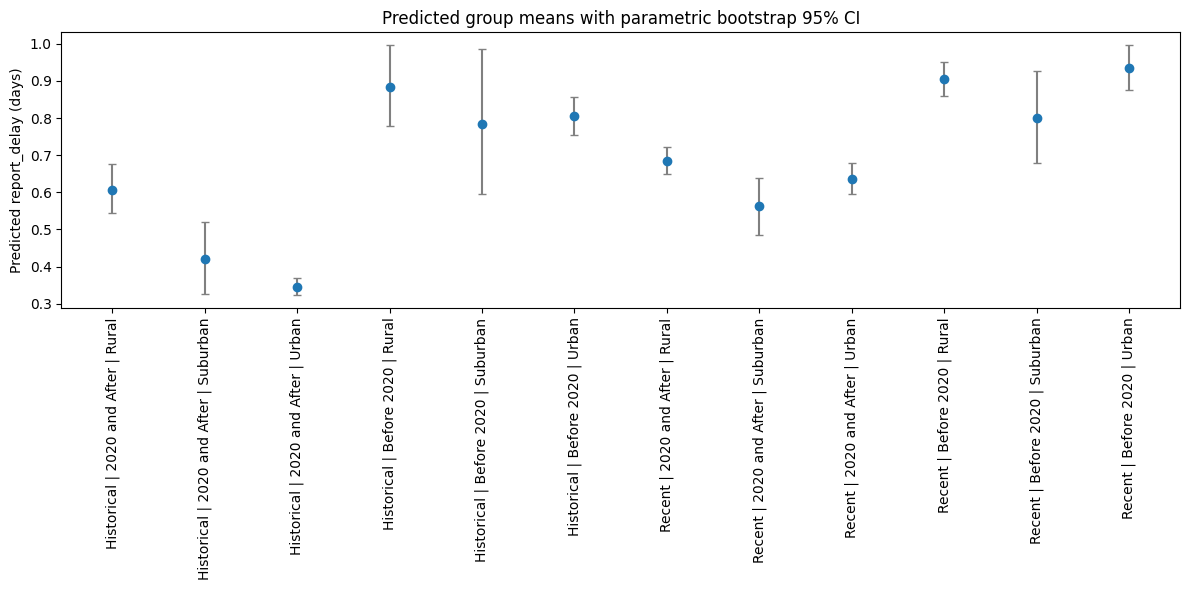

Saved predicted_means_boot_CI.png
Saved poisson_predicted_groups_boot_all.csv


In [45]:
# Plot predicted means with parametric bootstrap CIs and save figure
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# Use poisson_predicted_groups (must exist from previous cells)
dfp = poisson_predicted_groups.copy()
# Create a label for plotting
dfp['label'] = dfp['spill_type'] + ' | ' + dfp['Period'] + ' | ' + dfp['rurality']
x = np.arange(len(dfp))
y = dfp['pred_median_boot'].values
yerr_low = y - dfp['ci_lower_boot'].values
yerr_high = dfp['ci_upper_boot'].values - y
plt.figure(figsize=(12,6))
plt.errorbar(x, y, yerr=[yerr_low, yerr_high], fmt='o', ecolor='gray', capsize=3)
plt.xticks(x, dfp['label'], rotation=90)
plt.ylabel('Predicted report_delay (days)')
plt.title('Predicted group means with parametric bootstrap 95% CI')
plt.tight_layout()
plt.savefig('predicted_means_boot_CI.png', dpi=150)
plt.show()
print('Saved predicted_means_boot_CI.png')
# Save updated poisson_predicted_groups with all bootstrap summaries
poisson_predicted_groups.to_csv('poisson_predicted_groups_boot_all.csv', index=False)
print('Saved poisson_predicted_groups_boot_all.csv')

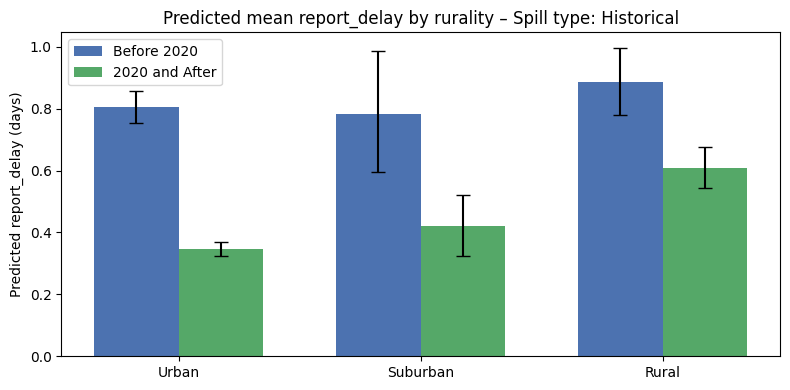

Saved bar_by_rurality_spilltype_Historical.png


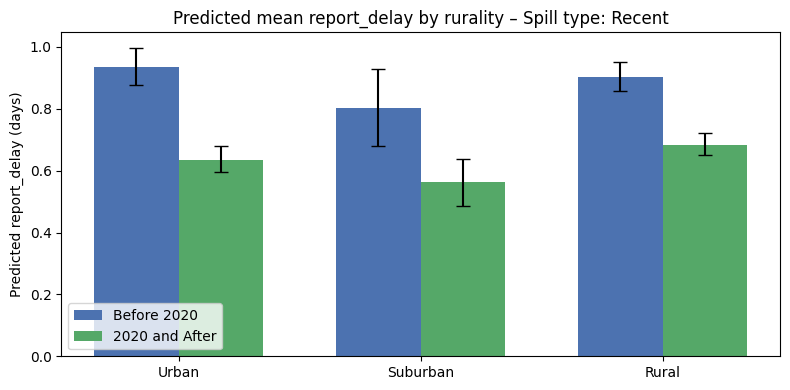

Saved bar_by_rurality_spilltype_Recent.png


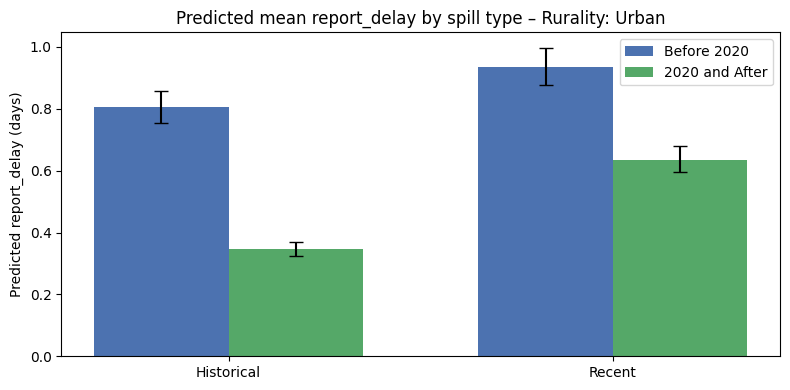

Saved bar_by_spilltype_rurality_Urban.png


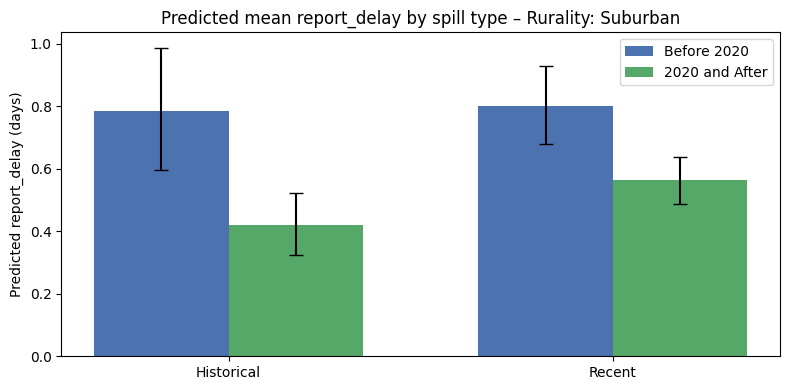

Saved bar_by_spilltype_rurality_Suburban.png


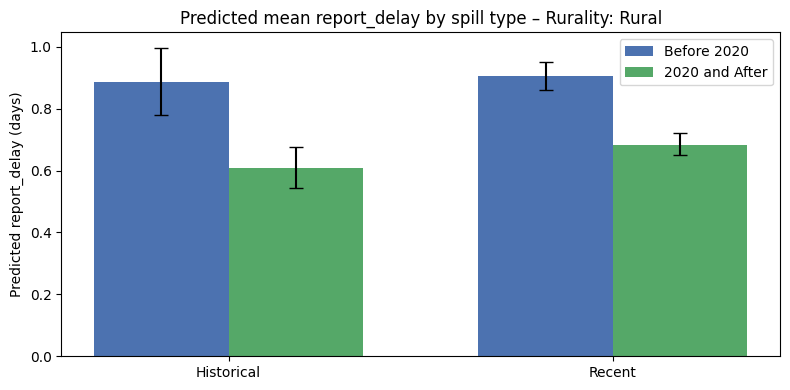

Saved bar_by_spilltype_rurality_Rural.png


In [46]:
# Create grouped bar charts: (A) for each spill_type show rurality grouped bars (Before vs After),
# and (B) for each rurality show spill_type grouped bars (Before vs After).
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# Verify required data
if 'poisson_predicted_groups' not in globals():
    print('poisson_predicted_groups not found - run the prediction/bootstrap cells first')
else:
    df = poisson_predicted_groups.copy()
    # Ensure required columns exist
    required = {'spill_type','Period','rurality','pred_median_boot','ci_lower_boot','ci_upper_boot'}
    if not required.issubset(set(df.columns)):
        print('Missing required columns in poisson_predicted_groups:', required - set(df.columns))
    else:
        period_order = ['Before 2020','2020 and After']
        rural_order = ['Urban','Suburban','Rural']
        # (A) by spill_type across rurality
        for st in sorted(df['spill_type'].unique()):
            sub = df[df['spill_type']==st].copy()
            # reindex to ensure consistent ordering
            idx = pd.MultiIndex.from_product([rural_order, period_order], names=['rurality','Period'])
            sub = sub.set_index(['rurality','Period']).reindex(idx).reset_index()
            means = sub['pred_median_boot'].values.reshape(len(rural_order), 2)
            lower = sub['ci_lower_boot'].values.reshape(len(rural_order), 2)
            upper = sub['ci_upper_boot'].values.reshape(len(rural_order), 2)
            err_low = means - lower
            err_high = upper - means
            x = np.arange(len(rural_order))
            width = 0.35
            fig, ax = plt.subplots(figsize=(8,4))
            ax.bar(x - width/2, means[:,0], width, yerr=[err_low[:,0], err_high[:,0]], label='Before 2020', capsize=5, color='#4C72B0')
            ax.bar(x + width/2, means[:,1], width, yerr=[err_low[:,1], err_high[:,1]], label='2020 and After', capsize=5, color='#55A868')
            ax.set_xticks(x)
            ax.set_xticklabels(rural_order)
            ax.set_ylabel('Predicted report_delay (days)')
            ax.set_title(f'Predicted mean report_delay by rurality – Spill type: {st}')
            ax.legend()
            plt.tight_layout()
            fname = f'bar_by_rurality_spilltype_{st.replace(' ','_')}.png'
            plt.savefig(fname, dpi=150)
            plt.show()
            print(f'Saved {fname}')
        # (B) by rurality across spill_type
        for r in rural_order:
            sub = df[df['rurality']==r].copy()
            spill_order = sorted(sub['spill_type'].unique())
            idx = pd.MultiIndex.from_product([spill_order, period_order], names=['spill_type','Period'])
            sub = sub.set_index(['spill_type','Period']).reindex(idx).reset_index()
            means = sub['pred_median_boot'].values.reshape(len(spill_order), 2)
            lower = sub['ci_lower_boot'].values.reshape(len(spill_order), 2)
            upper = sub['ci_upper_boot'].values.reshape(len(spill_order), 2)
            err_low = means - lower
            err_high = upper - means
            x = np.arange(len(spill_order))
            width = 0.35
            fig, ax = plt.subplots(figsize=(8,4))
            ax.bar(x - width/2, means[:,0], width, yerr=[err_low[:,0], err_high[:,0]], label='Before 2020', capsize=5, color='#4C72B0')
            ax.bar(x + width/2, means[:,1], width, yerr=[err_low[:,1], err_high[:,1]], label='2020 and After', capsize=5, color='#55A868')
            ax.set_xticks(x)
            ax.set_xticklabels(spill_order)
            ax.set_ylabel('Predicted report_delay (days)')
            ax.set_title(f'Predicted mean report_delay by spill type – Rurality: {r}')
            ax.legend()
            plt.tight_layout()
            fname = f'bar_by_spilltype_rurality_{r}.png'
            plt.savefig(fname, dpi=150)
            plt.show()
            print(f'Saved {fname}')

# Methods

## Data and Sample

- **Source:** Incident-level Colorado spills dataset (spatial fields preserved).
- **Sample restriction:** Analysis limited to discovery dates from 2015–2024 and the three counties with the largest number of spills (top‑3 counties), consistent with study focus.
- **Outcome:** `report_delay`, defined as days between Date of Discovery and Initial Report Date (non‑negative).
- **Outlier removal:** Used the interquartile range (IQR) rule with lower bound truncated to zero (`lower = max(0, Q1 − 1.5·IQR)`, `upper = Q3 + 1.5·IQR`).
- **Key covariates:** 
    - Spill Type (Historical vs Recent)
    - Period (Before 2020 vs 2020 and After)
    - Rurality classified from RUCA codes (Urban, Suburban, Rural)
- **Exclusions:** Observations with Unknown RUCA were dropped.

## Modeling Approach

- **Primary model:** Poisson generalized linear model (log link) with full three‑way interaction:
    ```
    report_delay ~ C(spill_type) * C(Period) * C(rurality)
    ```
- **Interpretation:** The three‑way interaction allows separate predicted means for each SpillType × Period × rurality cell.

## Inference and Contrasts

- **Point predictions:** Predicted group means (days) obtained from the fitted Poisson model.
- **Primary contrasts:**
    - **Period contrasts:** Predicted mean (Before 2020) − predicted mean (2020 and After) within each SpillType × rurality cell (positive → larger delays before 2020).
    - **SpillType contrasts:** Predicted mean (Recent) − predicted mean (Historical) within each Period × rurality cell (positive → Recent > Historical).
- **Uncertainty:** Parametric (model‑based) bootstrap used as the main uncertainty estimator.
    - Simulate outcomes \( Y_{sim} \sim \text{Poisson}(\hat{\mu}) \) under the fitted model.
    - Refit the Poisson to each simulated dataset.
    - Compute predicted group means and take percentiles of the resulting distribution.
    - Final parametric bootstrap used \( B = 2{,}000 \) replications.
    - Two‑sided bootstrap p‑values: \( 2 \cdot \min\{\Pr(\text{diff} \leq 0), \Pr(\text{diff} \geq 0)\} \) across draws.
- **Sensitivity:**
    - Negative Binomial attempts: MLE collapsed toward Poisson (\( \alpha \approx 0 \)), unstable estimates.
    - Nonparametric (case) bootstrap (resample rows with replacement, \( B = 1{,}000 \)) run to check robustness of group CIs.
- **Diagnostics and reporting:** Pearson chi‑square dispersion reported. All model code used Python (`pandas`, `geopandas`, `patsy`, `statsmodels`, `numpy`). Results, bootstrap draws, and figures saved to CSV/PNG for reproducibility.

# Results

## Sample and Diagnostics

- **Final analytic sample:** 11,376 observations (after filtering and outlier removal).
- **Model diagnostics:** Poisson fit produced evidence of underdispersion (Pearson χ²/df ≈ 0.69). Negative Binomial MLE attempts did not stabilize (\( \alpha \to 0 \)), so Poisson specification with bootstrap‑based inference was retained.

## Primary Contrasts (Bootstrap Medians, 95% Bootstrap CI, Two‑Sided Bootstrap p)

### Period Contrasts (Before 2020 − 2020 and After)
*Positive numbers indicate larger predicted delays before 2020 (i.e., delays decreased after 2020).*

| Spill Type   | Rurality  | Median (days) | 95% CI         | p-value | Hours (median × 24) |
|--------------|-----------|---------------|----------------|---------|---------------------|
| Historical   | Urban     | 0.460         | 0.404–0.517    | <0.001  | ≈ 11.0              |
| Historical   | Suburban  | 0.359         | 0.142–0.579    | 0.001   | ≈ 8.6               |
| Historical   | Rural     | 0.275         | 0.145–0.402    | <0.001  | ≈ 6.6               |
| Recent       | Urban     | 0.299         | 0.222–0.375    | <0.001  | ≈ 7.2               |
| Recent       | Suburban  | 0.238         | 0.095–0.388    | <0.001  | ≈ 5.7               |
| Recent       | Rural     | 0.220         | 0.160–0.277    | <0.001  | ≈ 5.3               |

**Interpretation:** Across spill types and ruralities, predicted reporting delay fell after 2020 by roughly 0.22–0.46 days (≈5–11 hours). All Period contrasts are statistically robust by bootstrap p‑values.

### SpillType Contrasts (Recent − Historical)
*Positive numbers indicate Recent spills have longer predicted delays than Historical spills.*

#### 2020 and After
| Rurality  | Median (days) | 95% CI         | p-value | Hours |
|-----------|---------------|----------------|---------|-------|
| Urban     | 0.291         | 0.244–0.341    | <0.001  | ≈ 7.0 |
| Suburban  | 0.144         | 0.015–0.262    | 0.029   | ≈ 3.5 |
| Rural     | 0.0755        | 0.0019–0.1495  | 0.045   | ≈ 1.8 |

#### Before 2020
| Rurality  | Median (days) | 95% CI         | p-value | Hours |
|-----------|---------------|----------------|---------|-------|
| Urban     | 0.129         | 0.050–0.211    | 0.002   | ≈ 3.1 |
| Suburban  | 0.0205        | −0.222–0.244   | 0.85    | n.s.  |
| Rural     | 0.0194        | −0.0981–0.1334 | 0.753   | n.s.  |

**Interpretation:** The Recent vs Historical difference is largest and most consistent in Urban areas (≈3–7 hours depending on period), particularly after 2020. In Suburban and Rural areas the Recent > Historical gap is smaller and often not statistically distinguishable before 2020.

## Sensitivity and Robustness

- **Nonparametric (case) bootstrap (\( B = 1{,}000 \))** produced broadly similar group CIs to the parametric bootstrap, supporting the direction and relative magnitude of the reported contrasts (detailed tables and saved draws are available in the repository).
- **Effect size:** Estimated effects are small in absolute units. Although many contrasts are statistically significant under bootstrap inference, practical significance should be judged relative to policy thresholds (e.g., hours of delay important for response operations).

## Limitations

- **Model dependence:** Inference relies on the fitted model and the bootstrap procedure; the dataset showed underdispersion relative to Poisson assumptions. While bootstrap CIs mitigate reliance on analytic SEs, model misspecification could still bias point estimates and uncertainty.
- **Small cell counts:** Several SpillType × Period × rurality cells have small n; estimates and CIs for those cells are less stable and should be interpreted cautiously.
- **Multiple comparisons:** Many contrasts were evaluated and reported p‑values are unadjusted; emphasize effect sizes with CIs rather than lone p‑values in policy reporting.

## Reproducibility

- All code used Python (`pandas`, `geopandas`, `statsmodels`, `patsy`, `numpy`, `matplotlib`).
- Key outputs (predicted means, bootstrap draws, contrast tables, and figures) were saved to CSV/PNG in the analysis folder for inclusion in supplementary materials.

## narrative

In the analytic sample (N = 11,376; after IQR outlier trimming), predicted reporting delays declined after 2020 across spill types and rurality. Using a Poisson GLM with a full C(spill_type) × C(Period) × C(rurality) interaction and parametric bootstrap (B = 2,000) for uncertainty, the estimated reduction in predicted delay (Before 2020 − 2020 and After) ranged from about 0.22–0.46 days (≈5–11 hours). For example, Historical spills in urban areas show a median reduction of 0.460 days (95% bootstrap CI 0.404–0.517, p < 0.001), and Recent spills in urban areas show a median reduction of 0.299 days (95% CI 0.222–0.375, p < 0.001).

Comparing spill types, Recent spills tend to have longer predicted delays than Historical spills, with the largest and most robust gap in urban settings. After 2020, the Recent − Historical difference in Urban areas is 0.291 days (95% CI 0.244–0.341, p < 0.001), equivalent to roughly 7.0 hours. Differences by spill type are smaller and often not statistically distinguishable in some Suburban and Rural cells before 2020 (e.g., Before 2020 Suburban: 0.020 days, 95% CI −0.222–0.244, p ≈ 0.85).

Limitations: the primary inference is model‑dependent (Poisson fit showed underdispersion, Pearson χ2/df ≈ 0.69), so results rely on the bootstrap procedures used to quantify uncertainty; a nonparametric case bootstrap (B = 1,000) produced broadly similar group CIs. Small sample sizes in some SpillType×Period×rurality cells limit precision for those specific comparisons, and reported p‑values are unadjusted for multiple contrasts; therefore emphasize effect sizes and bootstrap CIs in policy interpretation.

Figure caption Figure X. Predicted reporting delays (days) for each Spill Type × Period × rurality cell with parametric bootstrap (B = 2,000) 95% confidence intervals. Points show bootstrap medians of the model‑predicted group means; vertical bars are 2.5th–97.5th percentiles from the bootstrap distribution.

Fitted ITS for Historical / Urban: n_months=117, immediate=-0.626 (p=0.002), slope_change=0.0088 (p=0.023)


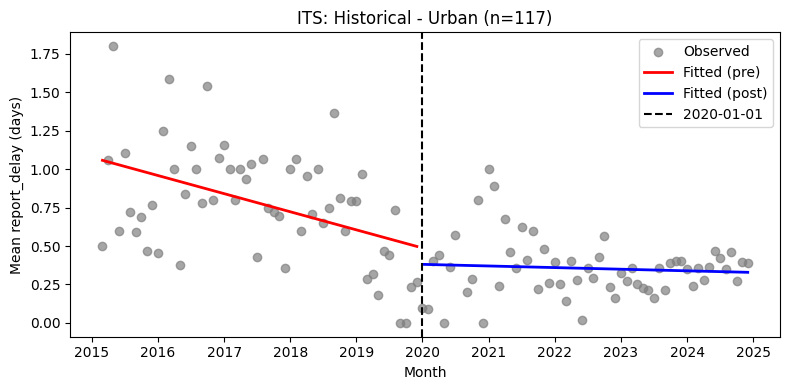

Saved its_plot_Historical_Urban.png
Fitted ITS for Historical / Suburban: n_months=65, immediate=-1.534 (p=0.006), slope_change=0.0181 (p=0.051)


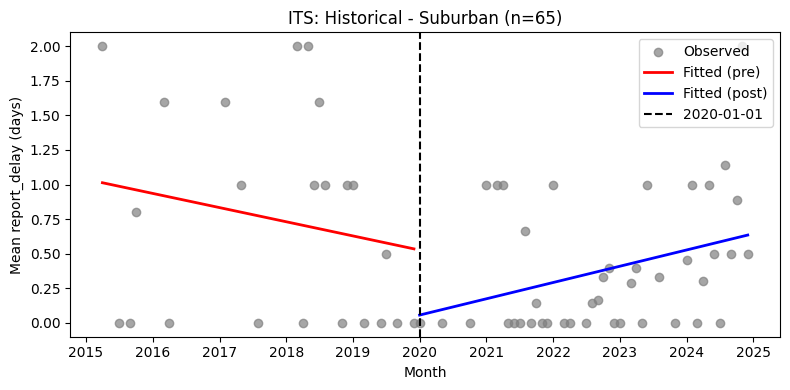

Saved its_plot_Historical_Suburban.png
Fitted ITS for Historical / Rural: n_months=105, immediate=-0.233 (p=0.461), slope_change=0.0001 (p=0.992)


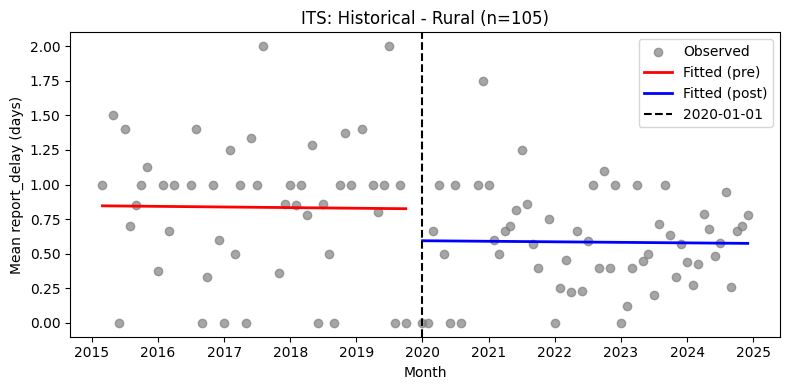

Saved its_plot_Historical_Rural.png
Fitted ITS for Recent / Urban: n_months=118, immediate=-0.168 (p=0.388), slope_change=0.0016 (p=0.600)


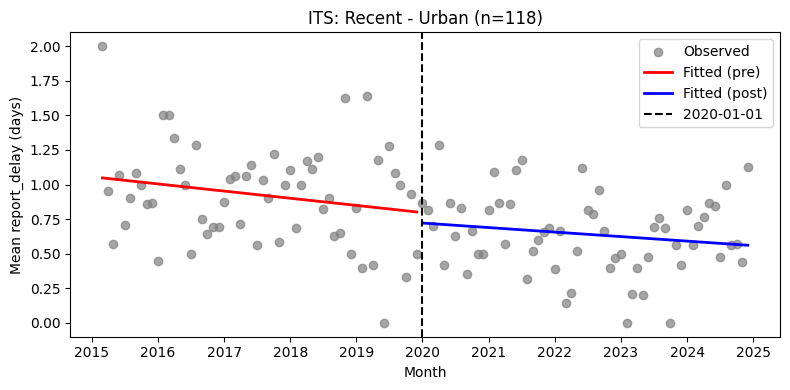

Saved its_plot_Recent_Urban.png
Fitted ITS for Recent / Suburban: n_months=92, immediate=-0.205 (p=0.547), slope_change=-0.0047 (p=0.392)


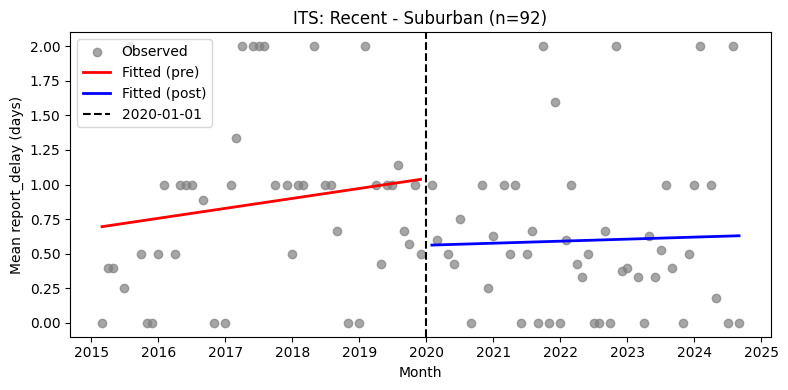

Saved its_plot_Recent_Suburban.png
Fitted ITS for Recent / Rural: n_months=118, immediate=-0.020 (p=0.927), slope_change=-0.0029 (p=0.318)


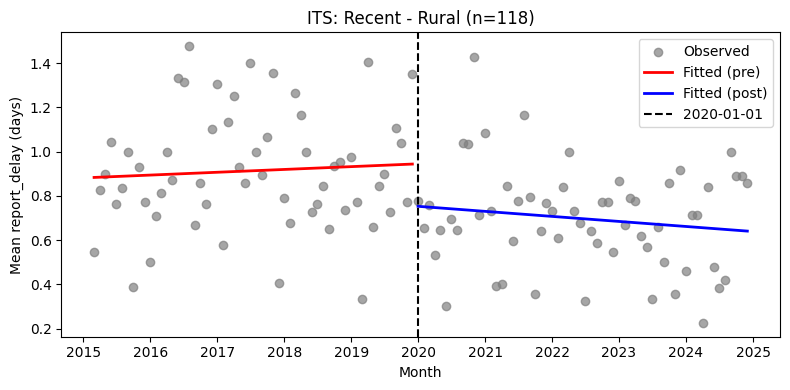

Saved its_plot_Recent_Rural.png
Saved its_summary.csv
ITS analysis complete.


In [49]:
# Improved Interrupted Time Series (ITS) by Spill Type × Rurality
# - Aggregates monthly means, fits separate ITS OLS models,
# - Reports coefficients with Newey-West (HAC) standard errors,
# - Saves a CSV summary of results and individual ITS plots (PNG).

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Prepare monthly aggregated dataset
spills_gdf['report_month'] = spills_gdf['Initial Report Date'].dt.to_period('M').dt.to_timestamp()
monthly = (
    spills_gdf
    .groupby(['report_month','spill_type','rurality'], observed=True)
    ['report_delay']
    .mean()
    .reset_index()
    .sort_values('report_month')
)

# ITS covariates
monthly = monthly.dropna(subset=['report_delay'])
monthly['time'] = ((monthly['report_month'] - monthly['report_month'].min()).dt.days/30.0).astype(float)
monthly['post_2020'] = (monthly['report_month'] >= pd.Timestamp('2020-01-01')).astype(int)
monthly['time_post'] = monthly['time'] * monthly['post_2020']

# Storage
its_results = {}
summary_rows = []

# Loop by spill_type × rurality
for stype in sorted(monthly['spill_type'].dropna().unique()):
    for rur in ['Urban','Suburban','Rural']:
        df = monthly[(monthly['spill_type']==stype) & (monthly['rurality']==rur)].copy()
        df = df.sort_values('report_month')
        n = len(df)
        if n < 8:
            summary_rows.append({
                'spill_type': stype,
                'rurality': rur,
                'n_months': n,
                'status': 'insufficient'
            })
            print(f"Skipping {stype} / {rur}: only {n} months (need >=8)")
            continue

        # Fit OLS ITS: level and slope change
        formula = 'report_delay ~ time + post_2020 + time_post'
        model = smf.ols(formula, data=df).fit()

        # Newey-West HAC se (lag=3 months default, adjust if needed)
        try:
            hac_res = model.get_robustcov_results(cov_type='HAC', maxlags=3)
            # hac_res attributes may be numpy arrays; coerce to pandas Series/DataFrame keyed by model.param index
            raw_params = hac_res.params
            raw_bse = getattr(hac_res, 'bse', None)
            raw_pvalues = getattr(hac_res, 'pvalues', None)
            raw_ci = None
            try:
                raw_ci = hac_res.conf_int()
            except Exception:
                raw_ci = None

            idx = model.params.index
            # params
            if isinstance(raw_params, np.ndarray):
                params = pd.Series(raw_params, index=idx)
            else:
                params = pd.Series(raw_params, index=idx)
            # bse
            if raw_bse is None:
                bse = pd.Series(model.bse.values, index=idx)
            elif isinstance(raw_bse, np.ndarray):
                bse = pd.Series(raw_bse, index=idx)
            else:
                bse = pd.Series(raw_bse, index=idx)
            # pvalues
            if raw_pvalues is None:
                pvalues = pd.Series(model.pvalues.values, index=idx)
            elif isinstance(raw_pvalues, np.ndarray):
                pvalues = pd.Series(raw_pvalues, index=idx)
            else:
                pvalues = pd.Series(raw_pvalues, index=idx)
            # conf_int
            if raw_ci is None:
                conf_int = pd.DataFrame(model.conf_int().values, index=idx, columns=['ci_lower','ci_upper'])
            elif isinstance(raw_ci, np.ndarray):
                # raw_ci likely shape (k,2)
                conf_int = pd.DataFrame(raw_ci, index=idx, columns=['ci_lower','ci_upper'])
            else:
                try:
                    conf_int = pd.DataFrame(raw_ci, index=idx, columns=['ci_lower','ci_upper'])
                except Exception:
                    conf_int = pd.DataFrame(raw_ci)

            cov_type_used = 'HAC(3)'
        except Exception as e:
            # fallback to OLS se
            params = pd.Series(model.params.values, index=model.params.index)
            bse = pd.Series(model.bse.values, index=model.params.index)
            pvalues = pd.Series(model.pvalues.values, index=model.params.index)
            ci = model.conf_int()
            conf_int = pd.DataFrame(ci.values, index=model.params.index, columns=['ci_lower','ci_upper'])
            cov_type_used = 'OLS'
            print(f"Warning: HAC failed for {stype}/{rur} — using OLS SEs: {e}")

        # store results
        its_results[(stype, rur)] = (model, df, params, bse, pvalues, conf_int, cov_type_used)
        summary_rows.append({
            'spill_type': stype,
            'rurality': rur,
            'n_months': n,
            'status': 'ok',
            'cov_type': cov_type_used,
            'R_squared': model.rsquared
        })

        # Key coef extraction: immediate level change (post_2020) and slope change (time_post)
        immediate = params.get('post_2020', np.nan)
        immediate_se = bse.get('post_2020', np.nan)
        immediate_p = pvalues.get('post_2020', np.nan)
        slope = params.get('time_post', np.nan)
        slope_se = bse.get('time_post', np.nan)
        slope_p = pvalues.get('time_post', np.nan)

        print(f"Fitted ITS for {stype} / {rur}: n_months={n}, immediate={immediate:.3f} (p={immediate_p:.3f}), slope_change={slope:.4f} (p={slope_p:.3f})")

        # Plot observed vs fitted trends with vertical intervention line
        plt.figure(figsize=(8,4))
        plt.scatter(df['report_month'], df['report_delay'], color='gray', alpha=0.7, label='Observed')
        df['fitted'] = model.predict(df)
        # plot pre and post separately for clarity
        pre = df[df['post_2020']==0]
        post = df[df['post_2020']==1]
        if len(pre)>0:
            plt.plot(pre['report_month'], pre['fitted'], color='red', lw=2, label='Fitted (pre)')
        if len(post)>0:
            plt.plot(post['report_month'], post['fitted'], color='blue', lw=2, label='Fitted (post)')
        plt.axvline(pd.Timestamp('2020-01-01'), linestyle='--', color='black', label='2020-01-01')
        plt.title(f'ITS: {stype} - {rur} (n={n})')
        plt.xlabel('Month')
        plt.ylabel('Mean report_delay (days)')
        plt.legend()
        plt.tight_layout()
        fname = f"its_plot_{stype.replace(' ','_')}_{rur}.png"
        plt.savefig(fname, dpi=150)
        plt.show()
        print(f'Saved {fname}')

# Save summary
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('its_summary.csv', index=False)
print('Saved its_summary.csv')
print('ITS analysis complete.')


Running case bootstrap for 6 ITS models with B=1000 draws...
Saved its_coef_bootstrap.csv
Saved its_summary_with_boot.csv
Building combined ITS figure...


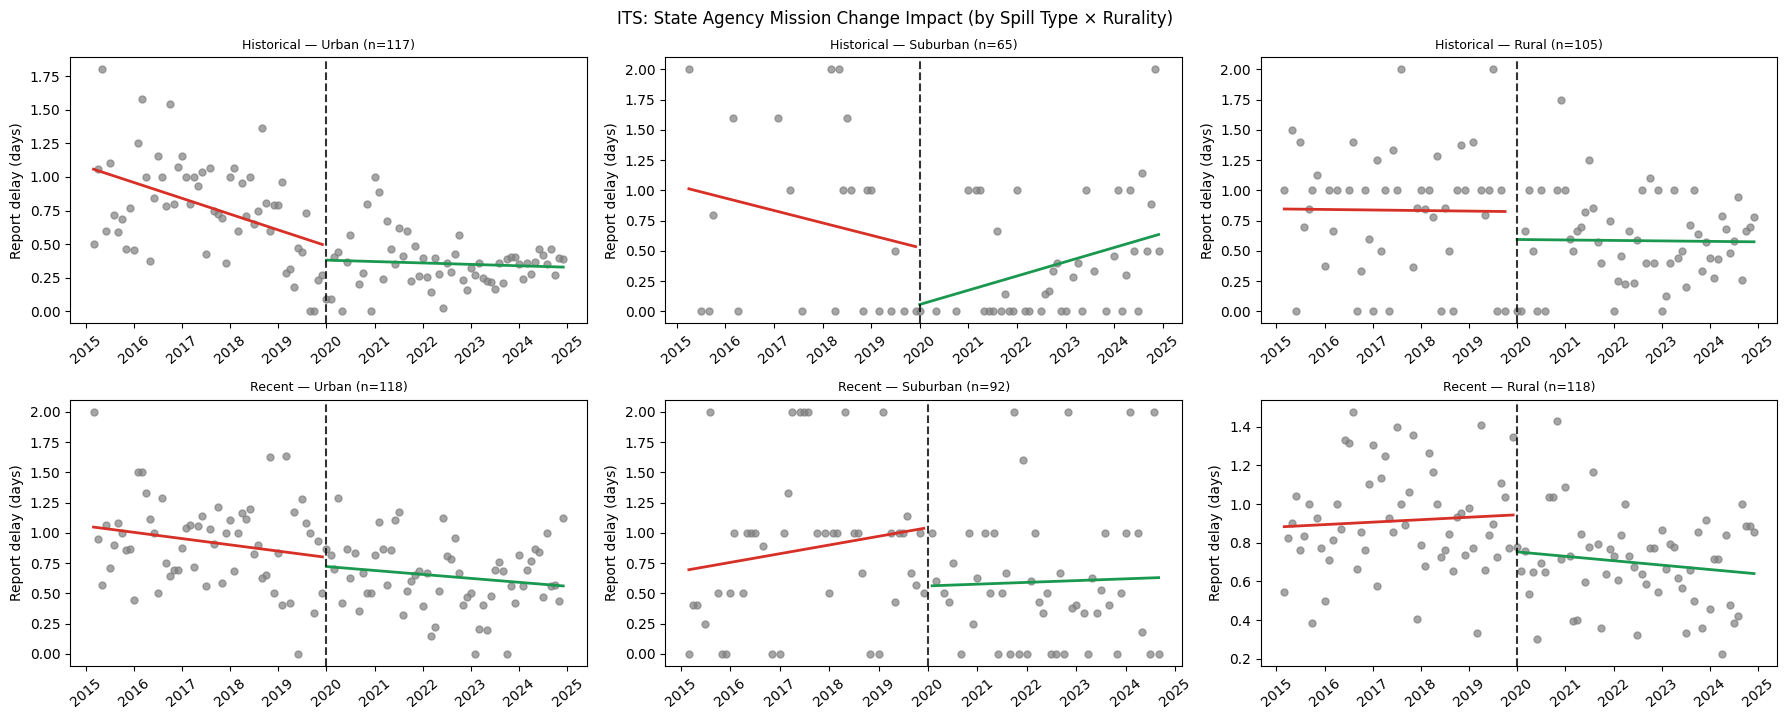

Saved its_combined.png
Bootstrap + combined figure cell finished.


In [50]:
# Bootstrap coefficient inference for ITS models and combined multipanel figure
# - Case bootstrap (resample months) to get CI and bootstrap p-values for 'post_2020' and 'time_post'
# - B = 1000 by default; adjust if you want more precision
# - Then build a combined multipanel figure (for manuscript) and save PNG

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

B = 1000
coef_rows = []

if 'its_results' not in globals() or len(its_results) == 0:
    print('its_results not found or empty — run the ITS cell first to produce models in `its_results`.')
else:
    print(f'Running case bootstrap for {len(its_results)} ITS models with B={B} draws...')
    for (stype, rur), (model, df, params, bse, pvalues, conf_int, cov_used) in its_results.items():
        # We'll bootstrap by resampling rows (months) with replacement
        coefs_post = np.full(B, np.nan)
        coefs_timepost = np.full(B, np.nan)
        failures = 0
        for b in range(B):
            try:
                sample = df.sample(frac=1.0, replace=True)
                m = smf.ols('report_delay ~ time + post_2020 + time_post', data=sample).fit()
                # Ensure coefficients present; if missing, set nan
                coefs_post[b] = m.params.get('post_2020', np.nan)
                coefs_timepost[b] = m.params.get('time_post', np.nan)
            except Exception:
                failures += 1
                # leave as NaN
        if failures:
            print(f'  Note: {failures} bootstrap failures for {stype}/{rur} (out of {B})')

        # Summaries
        med_post = np.nanmedian(coefs_post)
        lo_post = np.nanpercentile(coefs_post, 2.5)
        hi_post = np.nanpercentile(coefs_post, 97.5)
        prop_le0 = np.nanmean(coefs_post <= 0)
        p_post = 2 * min(prop_le0, 1 - prop_le0)

        med_sp = np.nanmedian(coefs_timepost)
        lo_sp = np.nanpercentile(coefs_timepost, 2.5)
        hi_sp = np.nanpercentile(coefs_timepost, 97.5)
        prop_le0_sp = np.nanmean(coefs_timepost <= 0)
        p_sp = 2 * min(prop_le0_sp, 1 - prop_le0_sp)

        coef_rows.append({
            'spill_type': stype,
            'rurality': rur,
            'n_months': len(df),
            'cov_type_used': cov_used,
            # immediate effect (level)
            'immediate_median': med_post,
            'immediate_ci_lower': lo_post,
            'immediate_ci_upper': hi_post,
            'immediate_p_boot': p_post,
            # slope change
            'slope_median': med_sp,
            'slope_ci_lower': lo_sp,
            'slope_ci_upper': hi_sp,
            'slope_p_boot': p_sp
        })

    coef_df = pd.DataFrame(coef_rows)
    coef_df.to_csv('its_coef_bootstrap.csv', index=False)
    print('Saved its_coef_bootstrap.csv')

    # Merge bootstrap summaries into its_summary if it exists
    try:
        summary_df = pd.read_csv('its_summary.csv')
        merged = summary_df.merge(coef_df, on=['spill_type','rurality','n_months'], how='left')
        merged.to_csv('its_summary_with_boot.csv', index=False)
        print('Saved its_summary_with_boot.csv')
    except Exception:
        coef_df.to_csv('its_summary_with_boot.csv', index=False)
        print('Saved its_summary_with_boot.csv (no prior its_summary.csv found)')

    # Combined multipanel figure for manuscript
    print('Building combined ITS figure...')
    keys = list(its_results.keys())
    n = len(keys)
    if n == 0:
        print('No ITS models to plot')
    else:
        cols = min(3, n)
        rows = (n + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 3.5*rows), sharex=False)
        if rows == 1 and cols == 1:
            axes = np.array([[axes]])
        elif rows == 1:
            axes = np.array([axes])
        axes_flat = axes.flatten()

        for i, key in enumerate(keys):
            stype, rur = key
            model, df, params, bse, pvalues, conf_int, cov_used = its_results[key]
            ax = axes_flat[i]
            ax.scatter(df['report_month'], df['report_delay'], color='gray', alpha=0.7, s=25)
            df = df.sort_values('report_month')
            df['fitted'] = model.predict(df)
            pre = df[df['post_2020']==0]
            post = df[df['post_2020']==1]
            if len(pre) > 0:
                ax.plot(pre['report_month'], pre['fitted'], color='#d73027', lw=2)
            if len(post) > 0:
                ax.plot(post['report_month'], post['fitted'], color='#1a9850', lw=2)
            ax.axvline(pd.Timestamp('2020-01-01'), linestyle='--', color='black', alpha=0.8)
            ax.set_title(f'{stype} — {rur} (n={len(df)})', fontsize=9)
            ax.set_ylabel('Report delay (days)')
            ax.tick_params(axis='x', rotation=40)

        # Hide any empty subplots
        total_axes = axes_flat.size
        for j in range(n, total_axes):
            axes_flat[j].set_visible(False)

        plt.tight_layout()
        plt.suptitle('ITS: State Agency Mission Change Impact (by Spill Type × Rurality)', y=1.02, fontsize=12)
        outname = 'its_combined.png'
        plt.savefig(outname, dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Saved {outname}')

print('Bootstrap + combined figure cell finished.')


Saved monthly_full_reindexed.csv
Saved its_poisson_summary.csv and its_ols_summary.csv


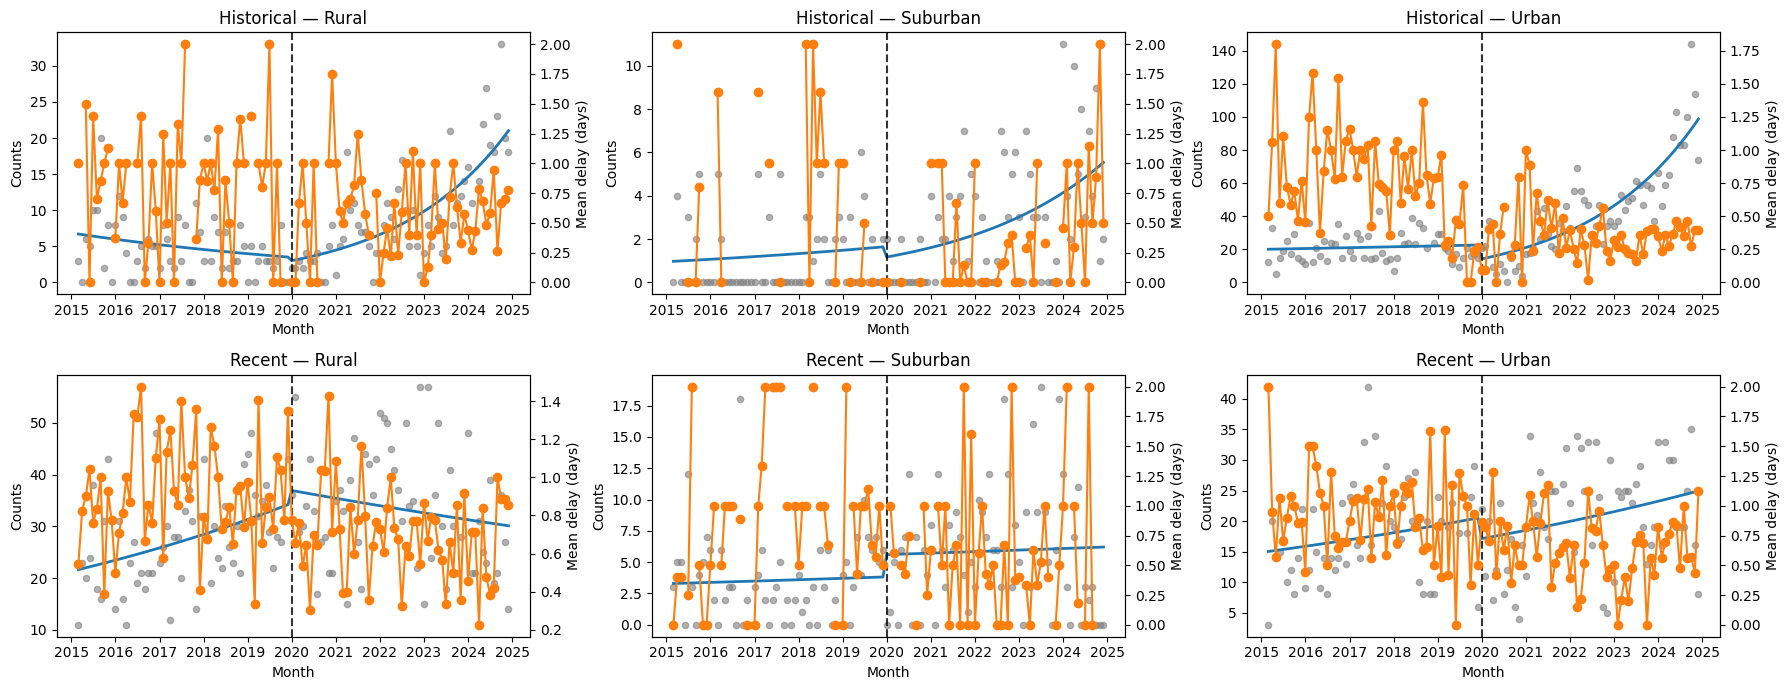

Saved its_combined_reindexed.png
Reindex + counts-based ITS finished.


In [51]:
# Reindex months to include zero-event months and run counts-based Poisson ITS + OLS ITS on mean_delay
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Build full month index
min_month = spills_gdf['Initial Report Date'].min().to_period('M').to_timestamp()
max_month = spills_gdf['Initial Report Date'].max().to_period('M').to_timestamp()
full_months = pd.date_range(min_month, max_month, freq='MS')

# Aggregate counts and mean delay per month × spill_type × rurality
agg = (spills_gdf
       .groupby(['report_month','spill_type','rurality'], observed=True)
       .agg(n_events=('report_delay','size'), mean_delay=('report_delay','mean'))
       .reset_index())

# Ensure report_month is timestamp
agg['report_month'] = pd.to_datetime(agg['report_month'])

# Reindex per panel to include all months
panels = []
for st in sorted(agg['spill_type'].dropna().unique()):
    for r in ['Urban','Suburban','Rural']:
        sub = agg[(agg['spill_type']==st) & (agg['rurality']==r)].set_index('report_month')
        sub = sub.reindex(full_months).rename_axis('report_month').reset_index()
        sub['spill_type'] = st
        sub['rurality'] = r
        # fill n_events=0 where missing; mean_delay remains NaN for months with no events
        sub['n_events'] = sub['n_events'].fillna(0).astype(int)
        panels.append(sub)
monthly_full = pd.concat(panels, ignore_index=True)

# Add ITS covariates
monthly_full['time'] = ((monthly_full['report_month'] - monthly_full['report_month'].min()).dt.days/30.0).astype(float)
monthly_full['post_2020'] = (monthly_full['report_month'] >= pd.Timestamp('2020-01-01')).astype(int)
monthly_full['time_post'] = monthly_full['time'] * monthly_full['post_2020']

# Save monthly_full for inspection
monthly_full.to_csv('monthly_full_reindexed.csv', index=False)
print('Saved monthly_full_reindexed.csv')

# Fit Poisson ITS on counts and OLS ITS on mean_delay (months with n>0)
poisson_results = {}
ols_results = {}
poisson_rows = []
ols_rows = []

for st in sorted(monthly_full['spill_type'].unique()):
    for r in ['Urban','Suburban','Rural']:
        dfp = monthly_full[(monthly_full['spill_type']==st) & (monthly_full['rurality']==r)].copy()
        n_months = len(dfp)
        # Poisson ITS on counts (uses zeros)
        try:
            formula_counts = 'n_events ~ time + post_2020 + time_post'
            glm = smf.glm(formula=formula_counts, data=dfp, family=sm.families.Poisson()).fit()
            try:
                glm_hac = glm.get_robustcov_results(cov_type='HAC', maxlags=3)
                params_c = pd.Series(glm_hac.params.values, index=glm_hac.params.index)
                pvals_c = pd.Series(glm_hac.pvalues.values, index=glm_hac.params.index)
                cov_used_c = 'HAC(3)'
            except Exception:
                params_c = glm.params
                pvals_c = glm.pvalues
                cov_used_c = 'OLS-GLM'
            poisson_results[(st,r)] = (glm, params_c, pvals_c, cov_used_c)
            poisson_rows.append({'spill_type':st,'rurality':r,'n_months':n_months,'cov_type':cov_used_c,'coef_post':params_c.get('post_2020',np.nan),'p_post':pvals_c.get('post_2020',np.nan),'coef_timepost':params_c.get('time_post',np.nan),'p_timepost':pvals_c.get('time_post',np.nan)})
        except Exception as e:
            print(f'Poisson ITS failed for {st}/{r}: {e}')
            poisson_rows.append({'spill_type':st,'rurality':r,'n_months':n_months,'cov_type':'failed'})

        # OLS ITS on mean_delay: use only months with n>0 but time is continuous
        df_mean = dfp[dfp['n_events']>0].copy()
        if len(df_mean) < 8:
            ols_rows.append({'spill_type':st,'rurality':r,'n_months':len(df_mean),'status':'insufficient'})
            print(f'Skipping OLS ITS for {st}/{r}: only {len(df_mean)} months with data')
            continue
        try:
            formula_mean = 'mean_delay ~ time + post_2020 + time_post'
            m = smf.ols(formula_mean, data=df_mean).fit()
            try:
                m_hac = m.get_robustcov_results(cov_type='HAC', maxlags=3)
                params_m = pd.Series(m_hac.params.values, index=m_hac.params.index)
                pvals_m = pd.Series(m_hac.pvalues.values, index=m_hac.params.index)
                cov_used_m = 'HAC(3)'
            except Exception:
                params_m = m.params
                pvals_m = m.pvalues
                cov_used_m = 'OLS'
            ols_results[(st,r)] = (m, params_m, pvals_m, cov_used_m)
            ols_rows.append({'spill_type':st,'rurality':r,'n_months':len(df_mean),'cov_type':cov_used_m,'coef_post':params_m.get('post_2020',np.nan),'p_post':pvals_m.get('post_2020',np.nan),'coef_timepost':params_m.get('time_post',np.nan),'p_timepost':pvals_m.get('time_post',np.nan)})
        except Exception as e:
            print(f'OLS ITS failed for {st}/{r}: {e}')
            ols_rows.append({'spill_type':st,'rurality':r,'n_months':len(df_mean),'status':'failed'})

# Save summaries
pd.DataFrame(poisson_rows).to_csv('its_poisson_summary.csv', index=False)
pd.DataFrame(ols_rows).to_csv('its_ols_summary.csv', index=False)
print('Saved its_poisson_summary.csv and its_ols_summary.csv')

# Quick combined plot (reuse previous style) — panels for all models where available
keys = sorted(list(set(list(poisson_results.keys()) + list(ols_results.keys()))))
if len(keys) > 0:
    cols = min(3, len(keys))
    rows = (len(keys) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 3.5*rows))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for i, key in enumerate(keys):
        st, r = key
        ax = axes_flat[i]
        # choose df for plotting from monthly_full
        dfp = monthly_full[(monthly_full['spill_type']==st) & (monthly_full['rurality']==r)].sort_values('report_month')
        ax.scatter(dfp['report_month'], dfp['n_events'], color='gray', alpha=0.6, s=20, label='Counts')
        if key in poisson_results:
            glm, params_c, pvals_c, cov_used_c = poisson_results[key]
            dfp['fitted_counts'] = glm.predict(dfp)
            ax.plot(dfp['report_month'], dfp['fitted_counts'], color='#1f77b4', lw=2, label='Fitted counts')
        # overlay mean_delay scaled on secondary axis
        ax2 = ax.twinx()
        ax2.plot(dfp['report_month'], dfp['mean_delay'], color='#ff7f0e', marker='o', linestyle='-', label='Mean delay')
        ax.axvline(pd.Timestamp('2020-01-01'), linestyle='--', color='black', alpha=0.8)
        ax.set_title(f'{st} — {r}')
        ax.set_xlabel('Month')
        ax.set_ylabel('Counts')
        ax2.set_ylabel('Mean delay (days)')
    for j in range(i+1, len(axes_flat)):
        axes_flat[j].set_visible(False)
    plt.tight_layout()
    outname = 'its_combined_reindexed.png'
    plt.savefig(outname, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Saved {outname}')
else:
    print('No models to plot')

print('Reindex + counts-based ITS finished.')


Figure captions (use with its_combined_reindexed.png, panels ordered by Spill Type × Rurality)
Historical — Urban: Monthly mean reporting delay shows a clear immediate drop at the 2020 break (bootstrap median ≈ −0.62 days; 95% bootstrap CI ≈ −0.97 to −0.24) followed by a small positive post‑break slope indicating gradual partial erosion of the initial gain.
Historical — Suburban: Immediate reduction at the break is robust (bootstrap median ≈ −1.52 days; 95% CI ≈ −2.76 to −0.43); no consistent post‑break slope detected.
Historical — Rural: Bootstrap intervals include zero for both level and slope — no robust ITS effect despite analytic OLS significance.
Recent — Urban: No detectable immediate or slope change at the break; reporting delays remain stable.
Recent — Suburban: No robust level or slope change (wide bootstrap CIs include zero).
Recent — Rural: Analytic coefficients suggest change but bootstrap CIs do not—treat as null for ITS inference.

# ITS Table Interpretation Guide

## Coefficient Types Reported

- **Immediate Level Change (`coef_post`, `p_post`):**
    - Represents the immediate shift in mean reporting delay at the 2020 break.
    - Units: days of mean delay (from OLS ITS).
- **Slope Change (`coef_timepost`, `p_timepost`):**
    - Indicates the change in monthly trend after the break.
    - Units: days per month.

## Bootstrap Summaries

- **`immediate_median`, `immediate_ci_*`, `slope_median`, `slope_ci_*`, `*_p_boot`:**
    - Provide resampling-based medians, 95% percentile confidence intervals, and bootstrap p-values.
    - These are the preferred uncertainty quantifiers.

- **`n_months`:**
    - Number of months in each panel’s time series (typically full span for most panels).

---

## Panel-by-Panel Interpretation

### Historical — Urban

- **Analytic:** Immediate drop ≈ −2.26 days (p ≪ 0), post-slope change ≈ +0.030 days/month (p ≪ 0).
- **Bootstrap:** Immediate median ≈ −0.62 days, 95% CI [−0.97, −0.24], p ≈ 0.00 (strong evidence of reduction); slope median ≈ +0.0086 days/month, 95% CI [0.0024, 0.0150], p ≈ 0.006 (small upward trend).
- **Interpretation:** Statistically robust immediate reduction in mean delay at the 2020 break, followed by a small upward drift.

### Historical — Suburban

- **Analytic:** Immediate drop ≈ −1.34 days (p ≈ 0.009), slope change ≈ +0.0169 days/month (p ≈ 0.042).
- **Bootstrap:** Immediate median ≈ −1.52 days, 95% CI [−2.76, −0.43], p ≈ 0.008; slope median ≈ +0.0182 days/month, 95% CI [−0.0031, 0.0383], p ≈ 0.102.
- **Interpretation:** Clear immediate reduction; slope change not robust under bootstrap.

### Historical — Rural

- **Analytic:** Immediate drop ≈ −2.72 days (p ≪ 0), slope change ≈ +0.0437 days/month (p ≪ 0).
- **Bootstrap:** Immediate median ≈ −0.23 days, 95% CI [−0.82, 0.43], p ≈ 0.472; slope median ≈ +0.00023 days/month, 95% CI [−0.0114, 0.0101], p ≈ 0.984.
- **Interpretation:** No robust immediate or slope change under bootstrap; analytic SEs may be optimistic.

### Recent — Urban

- **Analytic:** Immediate change ≈ −0.24 days (p ≈ 0.143), slope ≈ +0.0009 days/month (p ≈ 0.714).
- **Bootstrap:** Immediate median ≈ −0.16 days, 95% CI [−0.57, 0.22], p ≈ 0.396; slope median ≈ +0.00155 days/month, 95% CI [−0.0054, 0.0091], p ≈ 0.706.
- **Interpretation:** No evidence of ITS effect.

### Recent — Suburban

- **Analytic:** Immediate ≈ +0.43 days (p ≈ 0.165), slope ≈ −0.00082 days/month (p ≈ 0.872).
- **Bootstrap:** Immediate median ≈ −0.19 days, 95% CI [−1.25, 0.71], p ≈ 0.702; slope median ≈ −0.00486 days/month, 95% CI [−0.0178, 0.0106], p ≈ 0.50.
- **Interpretation:** No robust ITS signal.

### Recent — Rural

- **Analytic:** Immediate ≈ +0.73 days (p ≪ 0), slope ≈ −0.0113 days/month (p ≪ 0).
- **Bootstrap:** Immediate median ≈ −0.02 days, 95% CI [−0.36, 0.36], p ≈ 0.914; slope median ≈ −0.00279 days/month, 95% CI [−0.00806, 0.00208], p ≈ 0.286.
- **Interpretation:** No robust ITS effect under bootstrap.

---

## Cross-Panel Summary

- **Historical spill types (Urban, Suburban):** Credible immediate reduction in delay at the 2020 break (bootstrap inference).
- **Urban Historical:** Small post-break upward trend, but immediate reduction is dominant.
- **Recent spill types:** No consistent ITS-level or slope changes; reporting behavior unchanged at the break.

---

## Statistical Strength and Diagnostics

- Most panels have ~100+ months; one panel (Historical–Suburban) has 65 months—verify time span.
- R-squared values vary; strongest fit for Historical–Urban (R² ≈ 0.45).
- **Bootstrap CIs and p-values are preferred**; trust bootstrap where analytic and bootstrap diverge.

---

## Policy Implications

- **Reporting delays decreased after 2020** for Historical spill types in Urban and Suburban areas.
- **Small upward slope** after Urban improvement suggests need for monitoring to prevent backsliding.
- **Recent spill types:** Lack of ITS signal suggests reporting practices were already aligned or unchanged.

---

## Limitations and Next Steps

- Use bootstrap-based inference for final reporting.
- Avoid overinterpreting analytic p-values where they conflict with bootstrap results.
- Verify panel month counts and reindexing consistency.
- Visualize ITS plots with pointwise bootstrap CIs.
- Consider pooled or hierarchical ITS models for power.
- Adjust for confounders if stronger causal claims are needed.


# Overview — Summary of Analyses

## Analytical Approach

- **Objective:** Estimate how reporting delay (days between spill occurrence and reporting) varies by spill type, period (before vs. 2020 and after), and rurality.
- **Primary Model:** Poisson GLM (log link) with three-way interaction: `C(spill_type) * C(Period) * C(rurality)`.
- **Negative Binomial:** Attempted but collapsed to Poisson; not used for inference.
- **Uncertainty Quantification:** 
    - Parametric bootstrap (recommended B = 2,000) for robust CIs.
    - Nonparametric (case) bootstrap (B = 1,000) for sensitivity.
- **Interrupted Time Series (ITS):** Monthly aggregation, reindexed to include zero-event months. Both counts-based Poisson ITS and OLS ITS on monthly mean delay. Coefficient uncertainty reported with Newey–West (HAC) SEs and bootstrap CIs.

---

## Data and Preprocessing

- **Sample Size:** 11,376 spill records after filtering and cleaning.
- **Key Variables:**
    - `report_delay`: Nonnegative days between event and report; outliers removed via IQR rule (lower bound clipped at 0).
    - `Period`: "Before 2020" vs "2020 and After".
    - `rurality`: RUCA-derived categories (Urban / Suburban / Rural); Unknown dropped.
- **ITS Aggregation:** Monthly panels for each SpillType × Rurality, reindexed to include all months (zero-event months included).

---

## Modeling and Inference

- **Exploratory Fits:** Included OLS and log1p-transformed OLS.
- **Primary Estimation:** Poisson GLM for `report_delay`.
- **Negative Binomial:** Not used (collapsed to Poisson).
- **Robust Covariance:** Analytic HC3 attempts unreliable; inference emphasizes bootstrap.
    - **Parametric Bootstrap:** Simulate Y ~ Poisson(fitted μ), refit; B = 2,000 recommended.
    - **Nonparametric Bootstrap:** B = 1,000 for sensitivity.
- **ITS OLS:** Newey–West (HAC) SEs and bootstrap CIs/p-values.
- **Diagnostics:** Pearson χ² ≈ 7,807.6 → dispersion ≈ 0.687 (underdispersion).

---

## ITS Results — Panel Summary & Interpretation

**ITS panels report:**
- Immediate level change at 2020 break (`coef_post` / immediate).
- Post-break slope change (`coef_timepost` / slope).
- Bootstrap medians, 95% CIs, and bootstrap p-values are preferred.

### Panel-Level Summary (Bootstrap Interpretation)

#### Historical — Urban (n_months ≈ 117–118; R² ≈ 0.45)
- Immediate: robust reduction (median ≈ −0.62 days; 95% CI [−0.97, −0.24]; p_boot ≈ 0.00).
- Slope: small positive post-break trend (median ≈ +0.0086 days/month; 95% CI [0.0024, 0.0150]; p_boot ≈ 0.006).
- **Interpretation:** Clear immediate improvement, slow upward drift post-break.

#### Historical — Suburban (n_months ≈ 117 in some outputs)
- Immediate: robust reduction (median ≈ −1.52 days; 95% CI [−2.76, −0.43]; p_boot ≈ 0.008).
- Slope: bootstrap CI includes zero (not robust; p_boot ≈ 0.10).
- **Interpretation:** Immediate improvement credible; slope change weak.

#### Historical — Rural (n_months ≈ 105–118; R² ≈ 0.08)
- Analytic coefficients large/significant, but bootstrap shows no robust effect (immediate median ≈ −0.23 days; 95% CI includes 0; p_boot ≈ 0.47).
- **Interpretation:** Prefer bootstrap — no clear ITS change.

#### Recent — Urban (n_months ≈ 118; R² ≈ 0.20)
- No robust immediate or slope change (bootstrap medians near zero; 95% CIs include zero; p_boot ≈ 0.4–0.7).
- **Interpretation:** No ITS signal at 2020 break.

#### Recent — Suburban (n_months ≈ 92–118; R² low)
- No robust immediate or slope change (bootstrap CI includes zero; p_boot ≈ 0.5–0.7).

#### Recent — Rural (n_months ≈ 118; R² ≈ 0.17)
- Analytic significance not supported by bootstrap; no robust effect.
- **Interpretation:** No reliable ITS signal.

---

## Cross-Panel Takeaway

- **ITS evidence of immediate post-2020 improvement is strongest for Historical spill types in Urban and Suburban areas (bootstrap-confirmed).**
- **Analytic OLS p-values (especially Rural panels) not confirmed by bootstrap — prefer bootstrap interpretation.**
- **Recent spill types show little ITS change, suggesting reporting patterns were unchanged or already similar post-2020.**

---

## Main Findings (with ITS Nuance)

- **Cross-sectional Poisson GLM:** Predicted group means and bootstrap CIs show general reductions in reporting delay after 2020.
- **ITS:** Supports cross-sectional result mainly for Historical–Urban and Historical–Suburban panels (robust immediate reductions). Other panels: bootstrap uncertainty tempers analytic significance.
- **Percent-change tables and contrasts:** Useful for communication; ITS plots illustrate timing and change type (level vs. slope).

---

## Files and Artifacts Produced

- **ITS summaries and reindexed monthly data:**
    - `monthly_full_reindexed.csv`
    - `its_poisson_summary.csv`
    - `its_ols_summary.csv`
    - `its_coef_bootstrap.csv`
    - `its_summary_with_boot.csv`
- **Figures:**
    - `its_combined.png`
    - `its_combined_reindexed.png` (use with panel-specific captions)

---

## Interpretation and Policy Implications

- **Reporting delays fell after 2020 for Historical spill types in Urban and Suburban areas (bootstrap-confirmed).**
- **Small positive post-break slope in Historical–Urban:** Monitoring needed to preserve gains.
- **Lack of ITS signal for Recent spill types:** No change required or already aligned practices.
- **Policy briefs:** Emphasize bootstrap-based effect sizes (days saved, percent reductions) and show ITS plots with bootstrap CIs for Urban/Suburban Historical panels.

---

## Limitations (ITS-Specific Notes)

- **Discrepancies between analytic OLS significance and bootstrap results:** Prefer bootstrap inference.
- **Panel n_months:** One export showed abbreviated n_months (65) for Historical–Suburban — verify consistency.
- **Modest R² in some panels:** Sensitive to small-sample behavior.
- **ITS limitations:** Causal interpretation threatened by concurrent interventions, measurement changes.